## **Leukemia Prediction Based on Gene Expression Dataset**
> **Keywords**: leukemia, feature selection, regularization, logistic regression, machine learning

> **20251113** by Hazel


## **1. Introduction**
### **1.1 Leukemia**

Leukemia is a type of cancer that affects the blood and bone marrow. It disrupts the normal function of healthy blood cells. In bone marrow, various types of blood cells are produced by blood stem cells called hematopoietic stem cells. Leukemia develops when hematopoietic stem cells differentiate into abnormal white blood cells, crossing out healty blood cells and interfering their funcitons. Leukemia patients may become susceptible to infection and have anemia or easy bleeding.

Leukemia is broadly classified into **four main types** depending on the type of white blood cells affected and the rate at which the disease progresses. Based on whether leukemia affacts lymphoid or myeloid white blood cells, it is classified as lymphoblastic leukemia or myeloid leukemia. Also, depending on the proliferation speed, it is classified as 'acute' if it is rapid, or 'chronic' if it is slow growing. Those four types of leukemia are Acute Lymphoblastic Leukemia (**ALL**), Acute Myeloid Leukemia (**AML**), Chronic Lymphocytic Leukemia (**CLL**), and Chronic Myeloid Leukemia (**CML**).

Compared to chronic leukemias, acute leukemias need earlier and faster diagnosis as they progress more rapidly and aggressively. The appearance and symptoms of ALL and AML are highly similar. However, the cure rate is remarkably diminished when ALL therapy is used for AML. **Thus, accurate distinction of acute leukemias is crucial for successful treatment.** Since the mere inspection of the appearance of acute leukemias for classification has significant limitations, more systematic approach of gene expression monitoring is used.

### **1.2 Gene expression monitoring and DNA microarray**
DNA microarray is a powerful tool to analyze the expression levels of thousands of genes within a biological sample. This technology relies on the principle of complementary base pairing to detect and quantify nucleic acid sequences. A DNA chip consists of thousands of tiny spots on which DNA probes are fixed. A probe is a short single-stranded DNA sequence complementary to a certain gene. Each spot is coated with multiple identical DNA probes.

### **1.3 Data Source**
Thus, this study is attempting to classify leukemia patients into one of two classes (AML and ALL) using gene expression data.

The dataset comes from a proof-of-concept study published in 1999 by Golub et al. It showed how new cases of cancer could be classified by gene expression monitoring (via DNA microarray) and thereby provided a general approach for identifying new cancer classes and assigning tumors to known classes. These data were used to classify patients with acute myeloid leukemia (AML) and acute lymphoblastic leukemia (ALL).

There are two datasets containing the initial (training, 38 samples) and independent (test, 34 samples) datasets used in the paper. These datasets contain measurements corresponding to ALL and AML samples from Bone Marrow and Peripheral Blood. Intensity values have been re-scaled such that overall intensities for each chip are equivalent.

The dataset can also be found in [Kaggle](https://www.kaggle.com/datasets/crawford/gene-expression/code?datasetId=1868&sortBy=voteCount).


## **2. Data Preprocessing**

### **2.1 Load Data**

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import warnings
warnings.filterwarnings('ignore')

In [103]:
import random
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV, Lasso, ElasticNet
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification

In [39]:
os.chdir('/content/drive/MyDrive/leukemia-prediction-based-on-gene-expression')

In [40]:
# load train and test dataset
df_train = pd.read_csv('data/data_set_ALL_AML_train.csv')
df_test = pd.read_csv('data/data_set_ALL_AML_independent.csv')
label = pd.read_csv('data/actual.csv')

# view data
print(df_train.shape)
print(df_test.shape)
print(label.shape)

(7129, 78)
(7129, 70)
(72, 2)


In [41]:
# view the columns name
print(df_train.columns)
print(df_test.columns)

Index(['Gene Description', 'Gene Accession Number', '1', 'call', '2', 'call.1',
       '3', 'call.2', '4', 'call.3', '5', 'call.4', '6', 'call.5', '7',
       'call.6', '8', 'call.7', '9', 'call.8', '10', 'call.9', '11', 'call.10',
       '12', 'call.11', '13', 'call.12', '14', 'call.13', '15', 'call.14',
       '16', 'call.15', '17', 'call.16', '18', 'call.17', '19', 'call.18',
       '20', 'call.19', '21', 'call.20', '22', 'call.21', '23', 'call.22',
       '24', 'call.23', '25', 'call.24', '26', 'call.25', '27', 'call.26',
       '34', 'call.27', '35', 'call.28', '36', 'call.29', '37', 'call.30',
       '38', 'call.31', '28', 'call.32', '29', 'call.33', '30', 'call.34',
       '31', 'call.35', '32', 'call.36', '33', 'call.37'],
      dtype='object')
Index(['Gene Description', 'Gene Accession Number', '39', 'call', '40',
       'call.1', '42', 'call.2', '47', 'call.3', '48', 'call.4', '49',
       'call.5', '41', 'call.6', '43', 'call.7', '44', 'call.8', '45',
       'call.9', '46', 

In [42]:
df_train.head(3)

,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,A,-139,A,-76,A,-135,A,...,15,A,-318,A,-32,A,-124,A,-135,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,A,-73,A,-49,A,-114,A,...,-114,A,-192,A,-49,A,-79,A,-186,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,A,-1,A,-307,A,265,A,...,2,A,-95,A,49,A,-37,A,-70,A


### **1.2 Clean Data**
#### **1.2.1 Feature Engineering**
The dataset contains 7129 rows of genes. As for the columns, the number represents the patient's ID, and "call + number" indicates the expression status of a specific gene locus in a particular patient.

`call` represents the gene expression level, with three levels: A (Absent), P (Present), and M (Marginal), indicating low, high, and medium gene expression levels, respectively. Lower levels indicate lower confidence in the observed values, while higher levels indicate higher confidence. Genes with most observations showing "Absent" can be considered for removal.

In [43]:
# train dataset has 38 patients
call_columns_train = ['call', 'call.1',
       'call.2', 'call.3', 'call.4', 'call.5',
       'call.6', 'call.7', 'call.8', 'call.9', 'call.10',
       'call.11','call.12','call.13','call.14',
       'call.15','call.16','call.17','call.18',
       'call.19','call.20','call.21', 'call.22',
       'call.23','call.24','call.25', 'call.26',
       'call.27','call.28','call.29', 'call.30',
       'call.31', 'call.32','call.33', 'call.34',
       'call.35', 'call.36','call.37']

# test dataset has 34 patients
call_columns_test = ['call', 'call.1',
       'call.2', 'call.3', 'call.4', 'call.5',
       'call.6', 'call.7', 'call.8', 'call.9', 'call.10',
       'call.11','call.12','call.13','call.14',
       'call.15','call.16','call.17','call.18',
       'call.19','call.20','call.21', 'call.22',
       'call.23','call.24','call.25', 'call.26',
       'call.27','call.28','call.29', 'call.30',
       'call.31', 'call.32','call.33']

In [44]:
# analysis of call values ​​in the training and test datasets
for col in call_columns_train:
    proportion_A = (df_train[col] == 'A').sum() / len(df_train[col])
    print(f"{col}: {proportion_A:.4f}; ",end = '\t')

for col in call_columns_test:
    proportion_A = (df_test[col] == 'A').sum() / len(df_test[col])
    print(f"{col}: {proportion_A:.4f}; ", end = '\t')

call: 0.7018; 	call.1: 0.6535; 	call.2: 0.7113; 	call.3: 0.7028; 	call.4: 0.5797; 	call.5: 0.7395; 	call.6: 0.7258; 	call.7: 0.7383; 	call.8: 0.6625; 	call.9: 0.6986; 	call.10: 0.6757; 	call.11: 0.7495; 	call.12: 0.6169; 	call.13: 0.6467; 	call.14: 0.6123; 	call.15: 0.6746; 	call.16: 0.6643; 	call.17: 0.6760; 	call.18: 0.6876; 	call.19: 0.5999; 	call.20: 0.7391; 	call.21: 0.7385; 	call.22: 0.7489; 	call.23: 0.6643; 	call.24: 0.6781; 	call.25: 0.6784; 	call.26: 0.7903; 	call.27: 0.7308; 	call.28: 0.7760; 	call.29: 0.6949; 	call.30: 0.7049; 	call.31: 0.7192; 	call.32: 0.6814; 	call.33: 0.7126; 	call.34: 0.6671; 	call.35: 0.7221; 	call.36: 0.6807; 	call.37: 0.7115; 	call: 0.7549; 	call.1: 0.7318; 	call.2: 0.6838; 	call.3: 0.7211; 	call.4: 0.6176; 	call.5: 0.7607; 	call.6: 0.6915; 	call.7: 0.7182; 	call.8: 0.7294; 	call.9: 0.7297; 	call.10: 0.6663; 	call.11: 0.7237; 	call.12: 0.6608; 	call.13: 0.6577; 	call.14: 0.6099; 	call.15: 0.5879; 	call.16: 0.6737; 	call.17: 0.7481; 	call.18: 0.7485;

It can be seen that the proportion of absent expression levels for each gene is between 60-75%, with no extreme outliers. Therefore, the case of the call column is not considered for the time being, remove them directly.

In [45]:
# remove call columns
columns_to_remove_train = [col for col in df_train if 'call' in col]
train = df_train.drop(columns_to_remove_train, axis=1)

columns_to_remove_test = [col for col in df_test if 'call' in col]
test = df_test.drop(columns_to_remove_test, axis=1)

In [46]:
print(f"shape of train dataset: {train.shape}")
print(f"shape of test dataset: {test.shape}")
print(f"columns of train dataset: \n {train.columns}")
print(f"columns of test dataset: \n {test.columns}")

shape of train dataset: (7129, 40)
shape of test dataset: (7129, 36)
columns of train dataset: 
 Index(['Gene Description', 'Gene Accession Number', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17',
       '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '34', '35',
       '36', '37', '38', '28', '29', '30', '31', '32', '33'],
      dtype='object')
columns of test dataset: 
 Index(['Gene Description', 'Gene Accession Number', '39', '40', '42', '47',
       '48', '49', '41', '43', '44', '45', '46', '70', '71', '72', '68', '69',
       '67', '55', '56', '59', '52', '53', '51', '50', '54', '57', '58', '60',
       '61', '65', '66', '63', '64', '62'],
      dtype='object')


In [47]:
# Remember to adjust the column order
train_columns = ['Gene Description', 'Gene Accession Number', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38']

X_train_reindex = train.reindex(columns=train_columns)

test_columns = ['Gene Description', 'Gene Accession Number','39', '40', '41', '42', '43', '44', '45', '46',
       '47', '48', '49', '50', '51', '52', '53',  '54', '55', '56', '57', '58', '59',
       '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72']

X_test_reindex = test.reindex(columns=test_columns)

In [48]:
# view datasets after reindex
print(f"shape of train dataset: {X_train_reindex.shape}")
print(f"shape of test dataset: {X_test_reindex.shape}")
print(f"columns of train dataset: \n {X_train_reindex.columns}")
print(f"columns of test dataset: \n {X_test_reindex.columns}")

shape of train dataset: (7129, 40)
shape of test dataset: (7129, 36)
columns of train dataset: 
 Index(['Gene Description', 'Gene Accession Number', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17',
       '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '30', '31', '32', '33', '34', '35', '36', '37', '38'],
      dtype='object')
columns of test dataset: 
 Index(['Gene Description', 'Gene Accession Number', '39', '40', '41', '42',
       '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54',
       '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66',
       '67', '68', '69', '70', '71', '72'],
      dtype='object')


In [49]:
# Transpose the dataset, with patient IDs as the rows and genes as the columns
X_train = X_train_reindex.T
X_test = X_test_reindex.T

In [50]:
print(f"train dataset shape after transposing: {X_train.shape}")
print(f"test dataset shape after transposing: {X_test.shape}")
X_train.head()

train dataset shape after transposing: (40, 7129)
test dataset shape after transposing: (36, 7129)


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein ...,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypep...,PTGER3 Prostaglandin E receptor 3 (subtype EP3...,HMG2 High-mobility group (nonhistone chromosom...,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and ...,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41


In [51]:
# set the second row as columns name
X_train.columns = X_train.iloc[1]
X_test.columns = X_test.iloc[1]

In [52]:
X_train.head()

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein ...,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypep...,PTGER3 Prostaglandin E receptor 3 (subtype EP3...,HMG2 High-mobility group (nonhistone chromosom...,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and ...,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41


In [53]:
# delete the first 2 rows
X_train = X_train.iloc[2:]
X_test = X_test.iloc[2:]

In [54]:
print(f"train dataset shape after cleaning: {X_train.shape}")
print(f"test dataset shape after cleaning: {X_test.shape}")
X_train.head()

train dataset shape after cleaning: (38, 7129)
test dataset shape after cleaning: (34, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [55]:
# convert to numeric type
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [56]:
# save the temporary preprocessing results
X_train.to_csv('temp/X_train.csv', index = True)
X_test.to_csv('temp/X_test.csv', index = True)

In [57]:
# merge train and test dataset
merged_X = pd.concat([X_train, X_test], ignore_index = True, axis = 0)

In [58]:
print(f"dataset shape after merging: {merged_X.shape}")
merged_X.head()

dataset shape after merging: (72, 7129)


Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [59]:
# add cancer label
merged_XY = pd.concat([merged_X, label], axis = 1)

In [60]:
print(merged_XY.shape)
merged_XY.head(3)

(72, 7131)


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,patient,cancer
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,-125,389,-37,793,329,36,191,-37,1,ALL
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,-36,442,-17,782,295,11,76,-14,2,ALL
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,33,168,52,1138,777,41,228,-41,3,ALL


In [61]:
# save the result
merged_XY.to_csv('temp/merged_XY.csv')

In [62]:
# view the distribution of two types of leukemia
merged_XY['cancer'].value_counts()

,count
cancer,
ALL,47
AML,25


In [63]:
# encode the cancer type
cancer_mapping = {'ALL': 0, 'AML': 1}
merged_XY['cancer'] = merged_XY['cancer'].map(cancer_mapping)
merged_XY['cancer'].value_counts()

,count
cancer,
0,47
1,25


In [64]:
merged_XY.head(3)

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,patient,cancer
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,-125,389,-37,793,329,36,191,-37,1,0
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,-36,442,-17,782,295,11,76,-14,2,0
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,33,168,52,1138,777,41,228,-41,3,0


In [65]:
# standardize the gene data
# select the feature columns
gene_columns = merged_XY.columns.drop(['patient', 'cancer'])
merged_X = merged_X[gene_columns]

# normalization
scaler = StandardScaler()
scaler.fit(merged_X)
normalized_merged_X = scaler.transform(merged_X)
normalized_merged_X = pd.DataFrame(normalized_merged_X, columns=gene_columns)

# merge the standardization results with the labels
normalized_merged_XY = pd.concat([normalized_merged_X, merged_XY[['patient', 'cancer']]], axis=1)

In [66]:
# descriptive statistics
normalized_merged_X.describe()

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
count,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,...,7.200000e+01,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01
mean,-3.700743e-17,1.233581e-17,-6.167906e-18,-7.401487e-17,-1.233581e-16,-2.467162e-17,-2.467162e-17,1.218161e-16,8.018277e-17,-3.700743e-17,...,-9.868649e-17,0.000000,2.467162e-17,2.467162e-17,-6.167906e-17,0.000000,-7.709882e-17,1.233581e-17,2.158767e-17,-3.700743e-17
std,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,...,1.007018e+00,1.007018,1.007018e+00,1.007018e+00,1.007018e+00,1.007018,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00
min,-3.723748e+00,-3.884863e+00,-3.298759e+00,-2.028249e+00,-2.371131e+00,-2.773143e+00,-3.442400e+00,-2.745277e+00,-2.568900e+00,-2.508682e+00,...,-2.496279e+00,-1.901807,-3.263465e+00,-1.079620e+00,-3.604858e+00,-1.592384,-1.687031e+00,-4.859957e+00,-8.094092e-01,-3.994518e+00
25%,-3.442986e-01,-5.590956e-01,-5.677847e-01,-8.086744e-01,-7.495495e-01,-7.043834e-01,-5.534604e-01,-4.743955e-01,-8.343998e-01,-6.942782e-01,...,-6.776696e-01,-0.678129,-4.810226e-01,-4.836820e-01,-5.674910e-01,-0.583692,-6.349056e-01,-3.942695e-01,-5.003242e-01,-6.058415e-01
50%,1.451034e-01,1.689071e-01,-4.867377e-02,-9.313069e-02,2.126852e-01,1.423843e-02,2.574234e-02,1.582252e-01,-2.909606e-02,1.353849e-03,...,-2.510988e-02,-0.118168,1.699421e-01,-2.548845e-01,1.773409e-01,-0.176422,-4.361844e-02,-1.558378e-03,-3.477992e-01,5.184974e-02
75%,5.881410e-01,6.638442e-01,4.683853e-01,7.956736e-01,6.577445e-01,7.663624e-01,5.377399e-01,7.001114e-01,6.776565e-01,5.108932e-01,...,5.311705e-01,0.509317,6.567255e-01,1.993849e-01,6.996906e-01,0.525422,4.025900e-01,4.472544e-01,-9.762587e-02,6.719586e-01
max,2.066650e+00,1.541114e+00,2.626902e+00,2.175008e+00,3.027273e+00,1.836757e+00,2.736942e+00,1.811608e+00,2.285448e+00,3.455145e+00,...,2.542338e+00,3.243242,2.647065e+00,5.707152e+00,1.657332e+00,3.424295,3.925930e+00,2.365929e+00,4.453914e+00,2.720197e+00


In [67]:
# Descriptive statistics
normalized_merged_XY.describe()

,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,patient,cancer
count,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,...,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.00000,72.000000
mean,-3.700743e-17,1.233581e-17,-6.167906e-18,-7.401487e-17,-1.233581e-16,-2.467162e-17,-2.467162e-17,1.218161e-16,8.018277e-17,-3.700743e-17,...,2.467162e-17,2.467162e-17,-6.167906e-17,0.000000,-7.709882e-17,1.233581e-17,2.158767e-17,-3.700743e-17,36.50000,0.347222
std,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,...,1.007018e+00,1.007018e+00,1.007018e+00,1.007018,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,20.92845,0.479428
min,-3.723748e+00,-3.884863e+00,-3.298759e+00,-2.028249e+00,-2.371131e+00,-2.773143e+00,-3.442400e+00,-2.745277e+00,-2.568900e+00,-2.508682e+00,...,-3.263465e+00,-1.079620e+00,-3.604858e+00,-1.592384,-1.687031e+00,-4.859957e+00,-8.094092e-01,-3.994518e+00,1.00000,0.000000
25%,-3.442986e-01,-5.590956e-01,-5.677847e-01,-8.086744e-01,-7.495495e-01,-7.043834e-01,-5.534604e-01,-4.743955e-01,-8.343998e-01,-6.942782e-01,...,-4.810226e-01,-4.836820e-01,-5.674910e-01,-0.583692,-6.349056e-01,-3.942695e-01,-5.003242e-01,-6.058415e-01,18.75000,0.000000
50%,1.451034e-01,1.689071e-01,-4.867377e-02,-9.313069e-02,2.126852e-01,1.423843e-02,2.574234e-02,1.582252e-01,-2.909606e-02,1.353849e-03,...,1.699421e-01,-2.548845e-01,1.773409e-01,-0.176422,-4.361844e-02,-1.558378e-03,-3.477992e-01,5.184974e-02,36.50000,0.000000
75%,5.881410e-01,6.638442e-01,4.683853e-01,7.956736e-01,6.577445e-01,7.663624e-01,5.377399e-01,7.001114e-01,6.776565e-01,5.108932e-01,...,6.567255e-01,1.993849e-01,6.996906e-01,0.525422,4.025900e-01,4.472544e-01,-9.762587e-02,6.719586e-01,54.25000,1.000000
max,2.066650e+00,1.541114e+00,2.626902e+00,2.175008e+00,3.027273e+00,1.836757e+00,2.736942e+00,1.811608e+00,2.285448e+00,3.455145e+00,...,2.647065e+00,5.707152e+00,1.657332e+00,3.424295,3.925930e+00,2.365929e+00,4.453914e+00,2.720197e+00,72.00000,1.000000


#### **1.2.2 Missing Value Test**

In [68]:
# missing value count
null_counts = normalized_merged_XY.isnull().sum().max()

print('missing count:', null_counts)

missing count: 0


In [69]:
# save the final preprocessing result
normalized_merged_XY.to_csv('temp/normalized_merged_XY.csv')

## **2. Variable Selection**
Since the dataset contains over 7000 features but only 72 samples, it is a typical high-dimensional dataset. Therefore, dimensionality reduction must be performed before modeling. Due to the large number of features, a two-step dimensionality reduction method is considered: first, **statistical tests** are used to remove variables significantly irrelevant to leukemia classification; then, a series of **regularization** methods are used to further select features.

### **2.1 T-test**
The dataset is divided based on leukemia type (ALL and AML), followed by a t-test.

In [71]:
# devide the dataset
normalized_merged_XY_ALL = normalized_merged_XY[normalized_merged_XY['cancer'] == 0]
normalized_merged_XY_AML = normalized_merged_XY[normalized_merged_XY['cancer'] == 1]

print(f"ALL dataset shape: {normalized_merged_XY_ALL.shape}")
print(f"AML dataset shape: {normalized_merged_XY_AML.shape}")

ALL dataset shape: (47, 7131)
AML dataset shape: (25, 7131)


In [72]:
# only genetic feature variables are retained
normalized_merged_X_ALL = normalized_merged_XY_ALL.drop(['patient', 'cancer'], axis=1)
normalized_merged_X_AML = normalized_merged_XY_AML.drop(['patient', 'cancer'], axis=1)

In [73]:
# t-test
from scipy.stats import ttest_ind, f_oneway
from statsmodels.stats.multitest import fdrcorrection

results = []
for gene in normalized_merged_X_ALL.columns:
    t_value, p_value = ttest_ind(normalized_merged_X_ALL[gene], normalized_merged_X_AML[gene], equal_var=False)
    results.append((gene, t_value, p_value))

# save t-test results to the dataframe
ttest_results = pd.DataFrame(results, columns=['Gene Accession Number', 'T_Value', 'P_Value'])

# Adjust p-values for multiple testing using False Discovery Rate (FDR) correction
rejected, adjusted_p_values = fdrcorrection(ttest_results['P_Value'])

In [75]:
print(f"t-test results shape: {ttest_results.shape}")
ttest_results.head()

t-test results shape: (7129, 3)


,Gene Accession Number,T_Value,P_Value
0,AFFX-BioB-5_at,-1.047809,0.298878
1,AFFX-BioB-M_at,1.296689,0.203744
2,AFFX-BioB-3_at,-0.341101,0.734072
3,AFFX-BioC-5_at,-2.346896,0.023870
4,AFFX-BioC-3_at,1.399006,0.168058


In [76]:
# select the significant genes
# set the threshould of significant level
threshold = 0.05

# get the significant genes
significant_genes = ttest_results[rejected & (adjusted_p_values < threshold)]

# sort significant genes based on p-values
significant_genes = significant_genes.sort_values(by='P_Value')

# add rank to significant genes dataFrame
significant_genes['Rank'] = significant_genes['P_Value'].rank()

# display the results
print(f"{len(significant_genes)} significant genes in total")
print(f"percent of significant genes: {len(significant_genes) / 7129}")
significant_genes.head()

1056 significant genes in total
percent of significant genes: 0.1481273670921588


,Gene Accession Number,T_Value,P_Value,Rank
4327,X59417_at,8.893281,2.958824e-12,1.0
2353,M92287_at,8.829048,6.432666e-12,2.0
6854,M31523_at,8.733946,1.179739e-11,3.0
6280,M31211_s_at,7.991861,1.974664e-11,4.0
2641,U05259_rna1_at,8.443672,4.119695e-11,5.0


In [77]:
# save the t-test results
significant_genes.to_csv('temp/significant_genes.csv')

A total of 1056 genes are significant, here we use heatmaps to visualize the significant influence.

In the heatmap, the left half represents ALL patients, and the right half represents AML patients. The first two heatmaps based on significant genes show a significant difference in gene expression levels between ALL and AML patients. The latter two heatmaps for insignificant genes are more cluttered, indicating no significant difference in gene expression levels between the two types of patients. Therefore, these genes do not have a significant impact on leukemia classification.

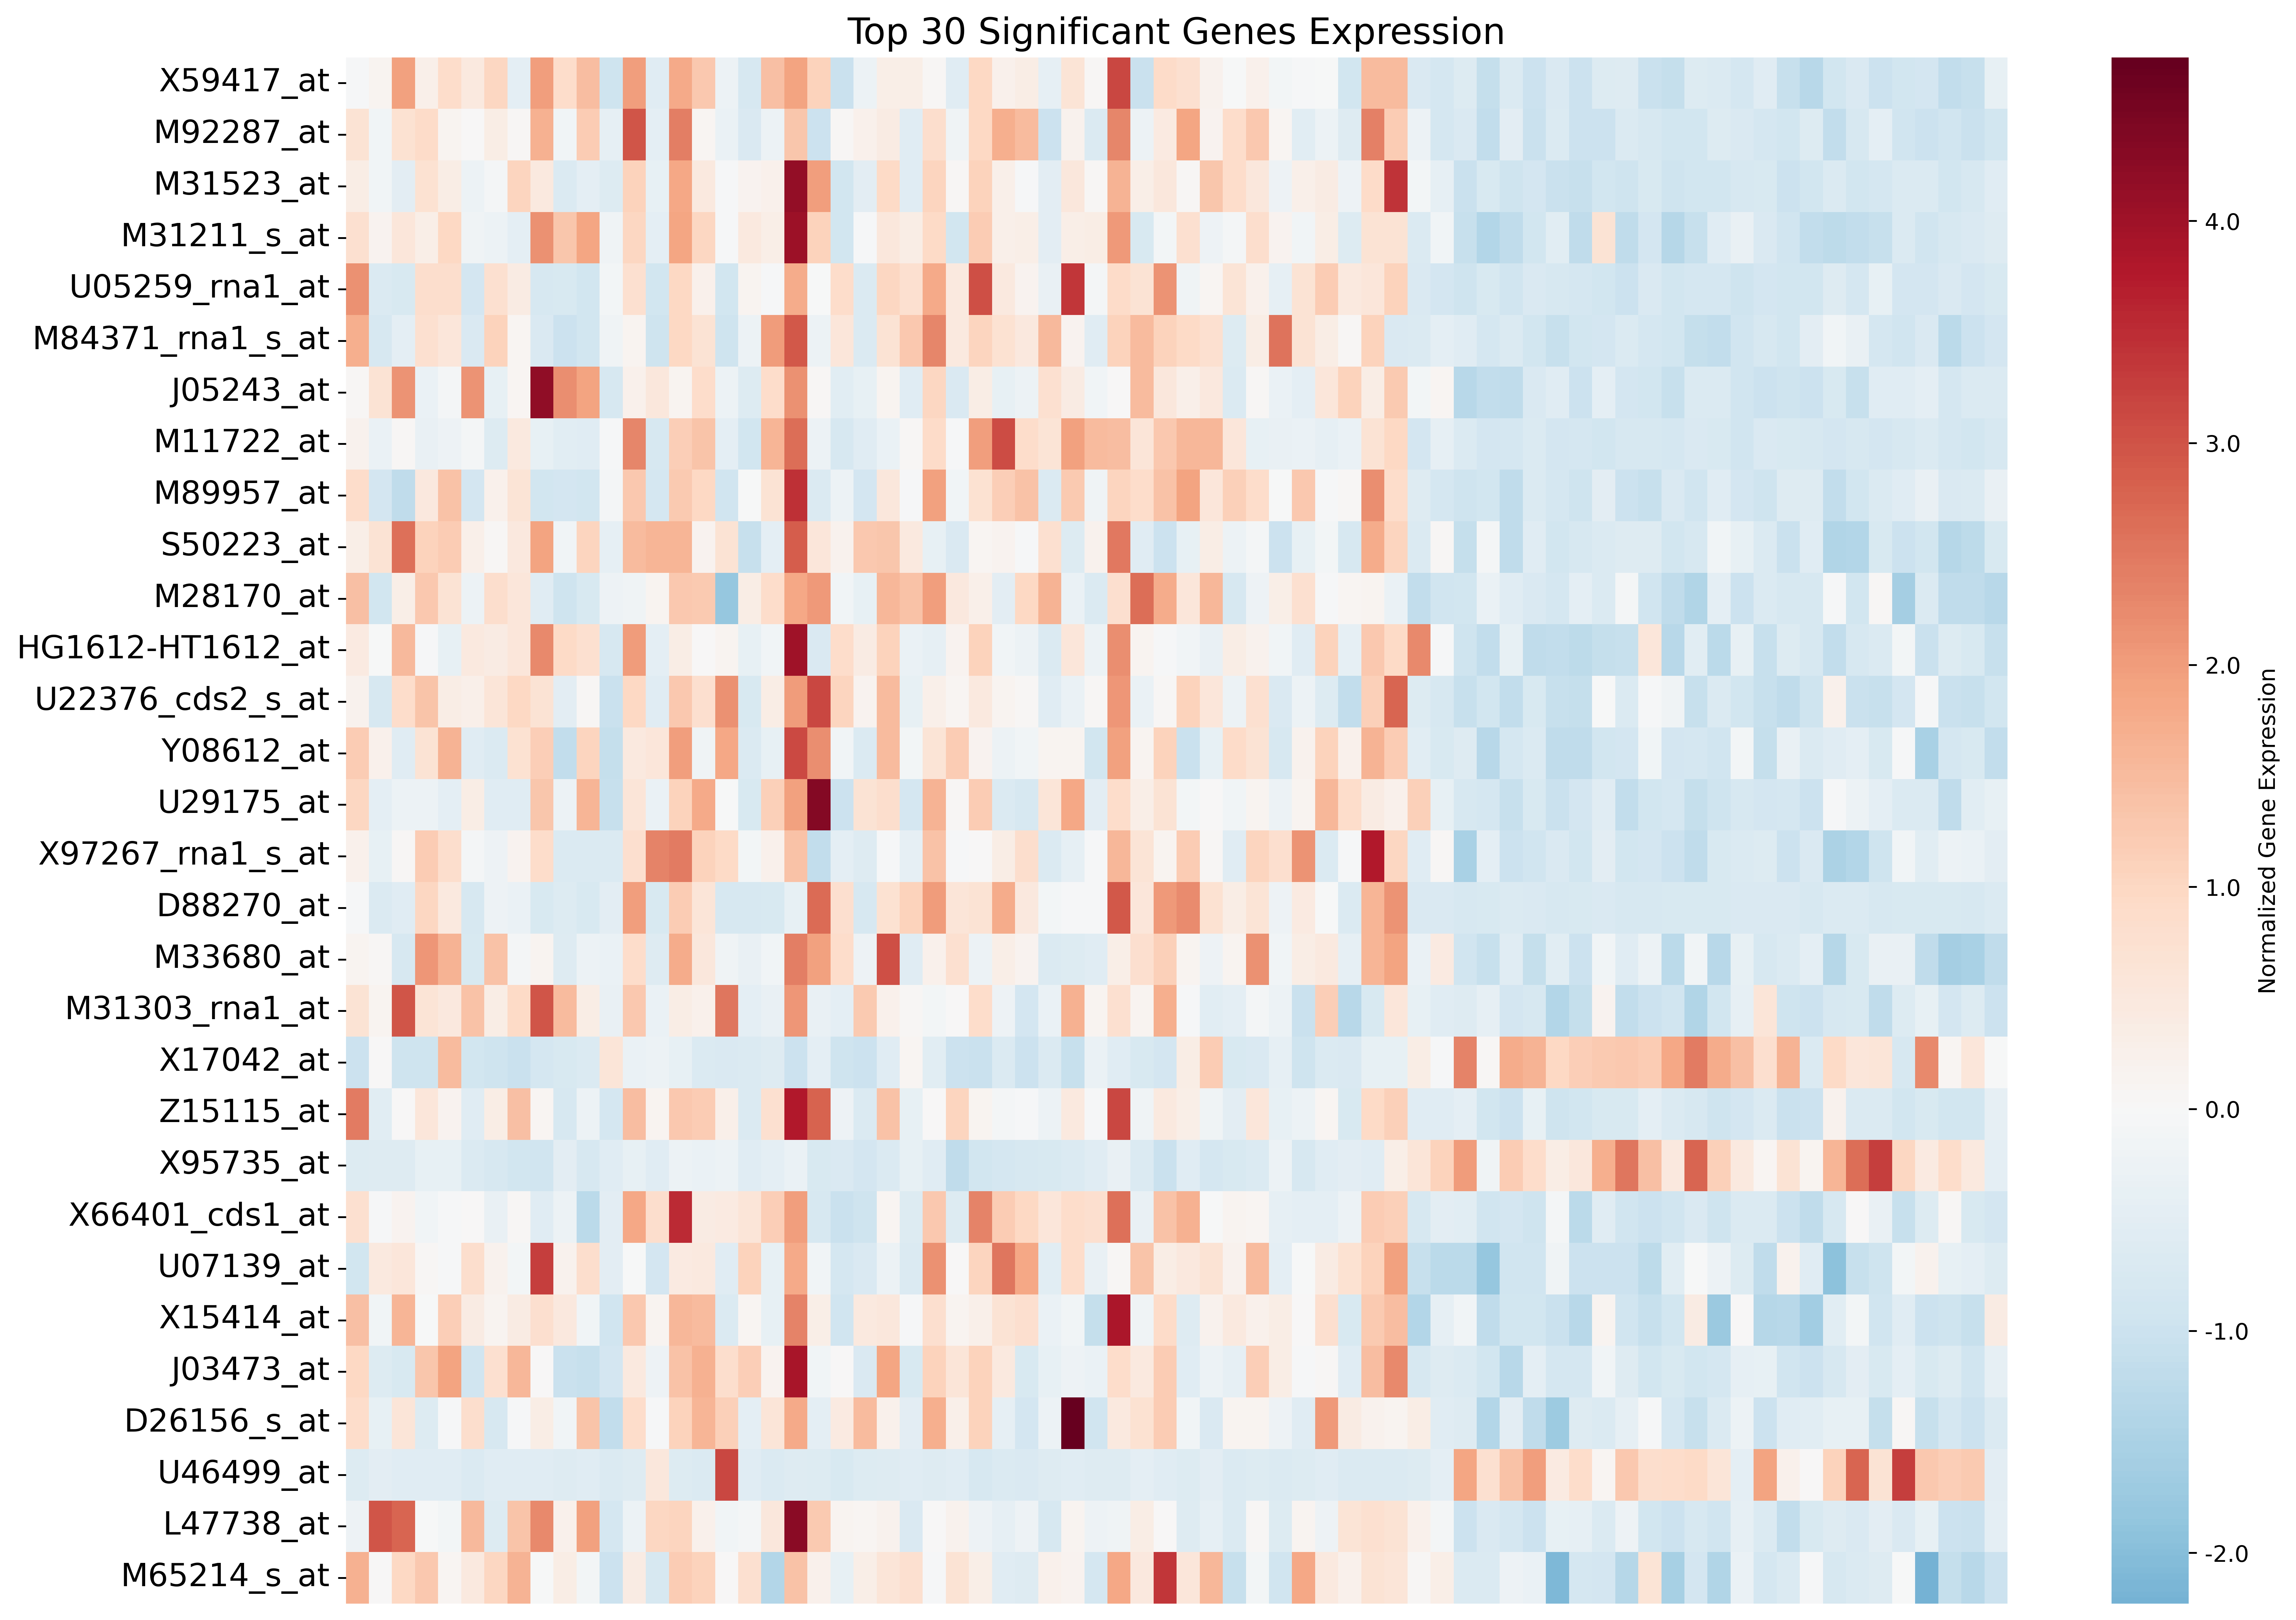

In [80]:
# get the top 30 significant genes
top_genes = significant_genes['Gene Accession Number'].head(30).tolist()

# select those genes columns from dataset
selected_data = normalized_merged_XY[top_genes]

# add cancer label for classification
selected_data['cancer'] = normalized_merged_XY['cancer']

# divide the two types of cancer by sorting
selected_data = selected_data.sort_values('cancer')

# transpose the dataset
plot_data = selected_data.drop('cancer', axis=1).T

plt.figure(figsize=(15, 10), dpi = 450)

sns.heatmap(plot_data,
            cmap='RdBu_r',
            cbar_kws={'label': 'Normalized Gene Expression',
                      'format': '%s'},
            center=0,
            yticklabels=True,
            xticklabels=False)

plt.title('Top 30 Significant Genes Expression',fontsize = 16)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('plt/top30-sig-gene-heatmap.png', dpi=450, bbox_inches='tight')
plt.show()

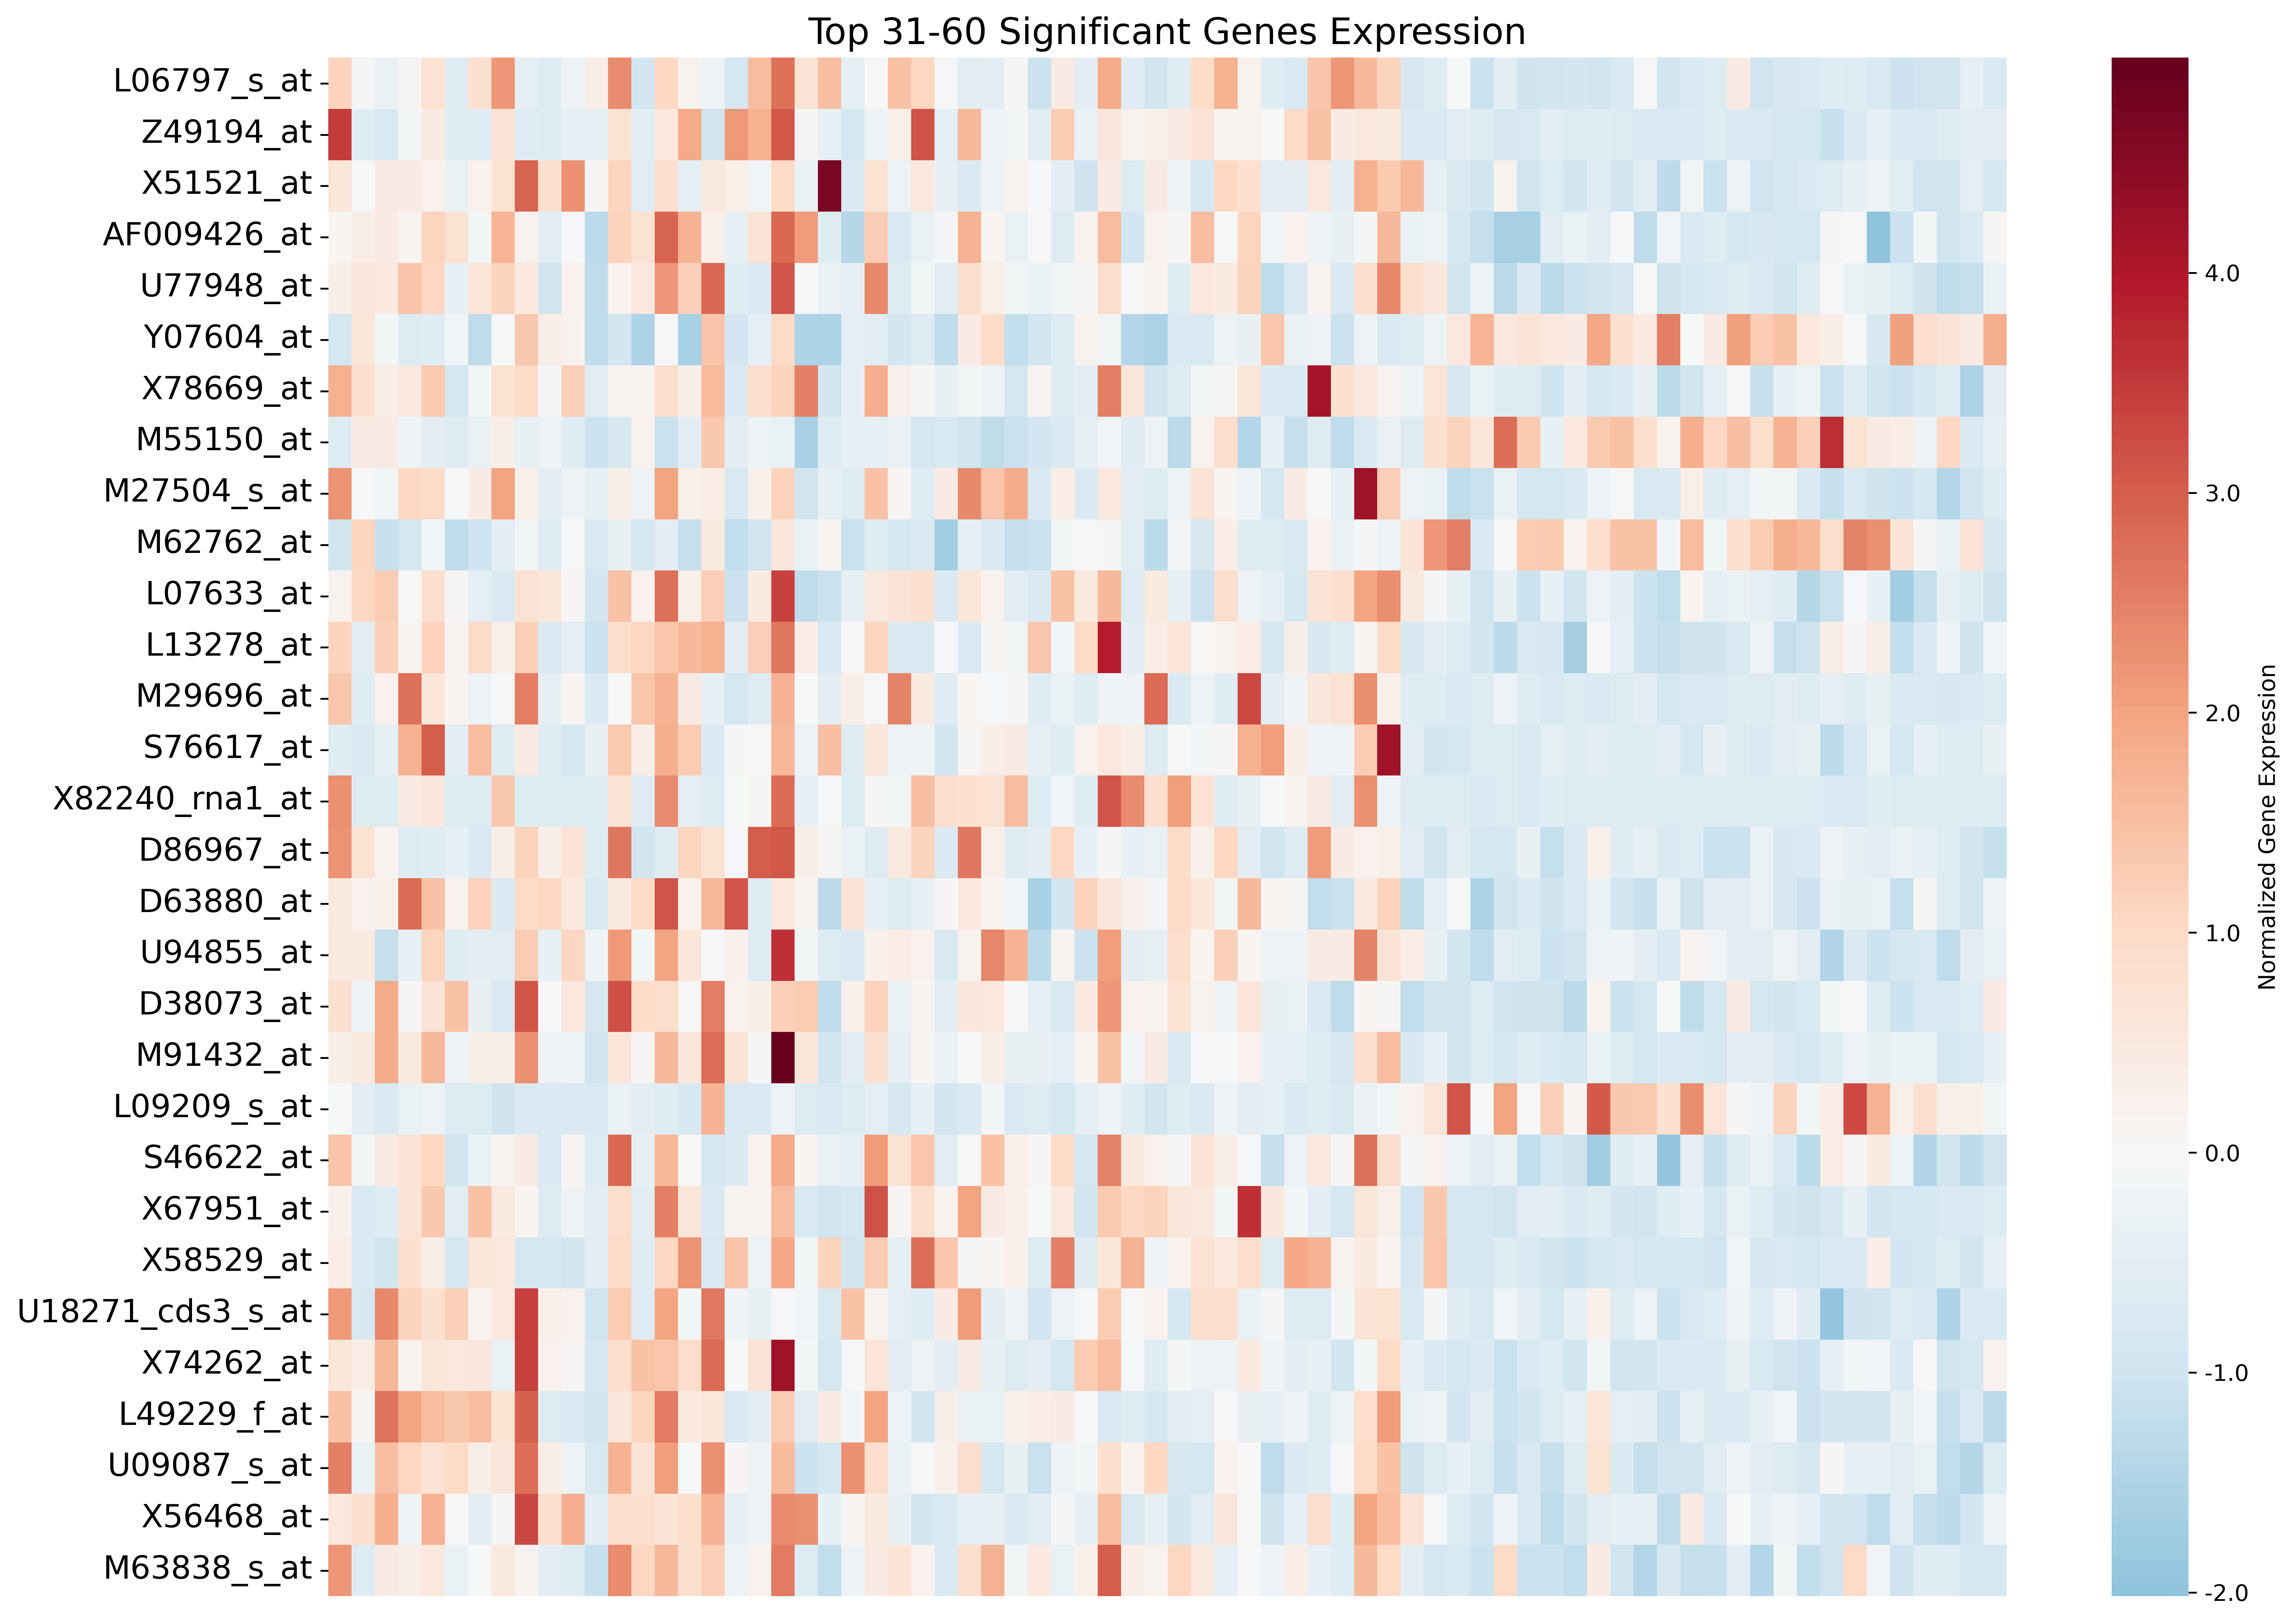

In [81]:
# get the top 31-60 significant genes
top_genes = significant_genes['Gene Accession Number'].iloc[30:60].tolist()

selected_data = normalized_merged_XY[top_genes]

selected_data['cancer'] = normalized_merged_XY['cancer']

selected_data = selected_data.sort_values('cancer')

plot_data = selected_data.drop('cancer', axis=1).T

plt.figure(figsize=(15, 10), dpi = 450)

sns.heatmap(plot_data,
            cmap='RdBu_r',
            cbar_kws={'label': 'Normalized Gene Expression',
                      'format': '%s'},
            center=0,
            yticklabels=True,
            xticklabels=False)

plt.title('Top 31-60 Significant Genes Expression',fontsize = 16)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('plt/top60-sig-gene-heatmap.png', dpi=450, bbox_inches='tight')
plt.show()

Draw a diagram to contrast the last 30 insignificant genes.

In [82]:
ttest_results_sort = ttest_results.sort_values(by='P_Value')
ttest_results_sort.tail()

,Gene Accession Number,T_Value,P_Value
4307,X57766_at,-0.002122,0.998315
6497,U18297_s_at,0.001437,0.998859
4967,Y08302_at,0.001308,0.998961
1012,HG4660-HT5073_at,0.000991,0.999213
4153,X14894_at,-0.000650,0.999484


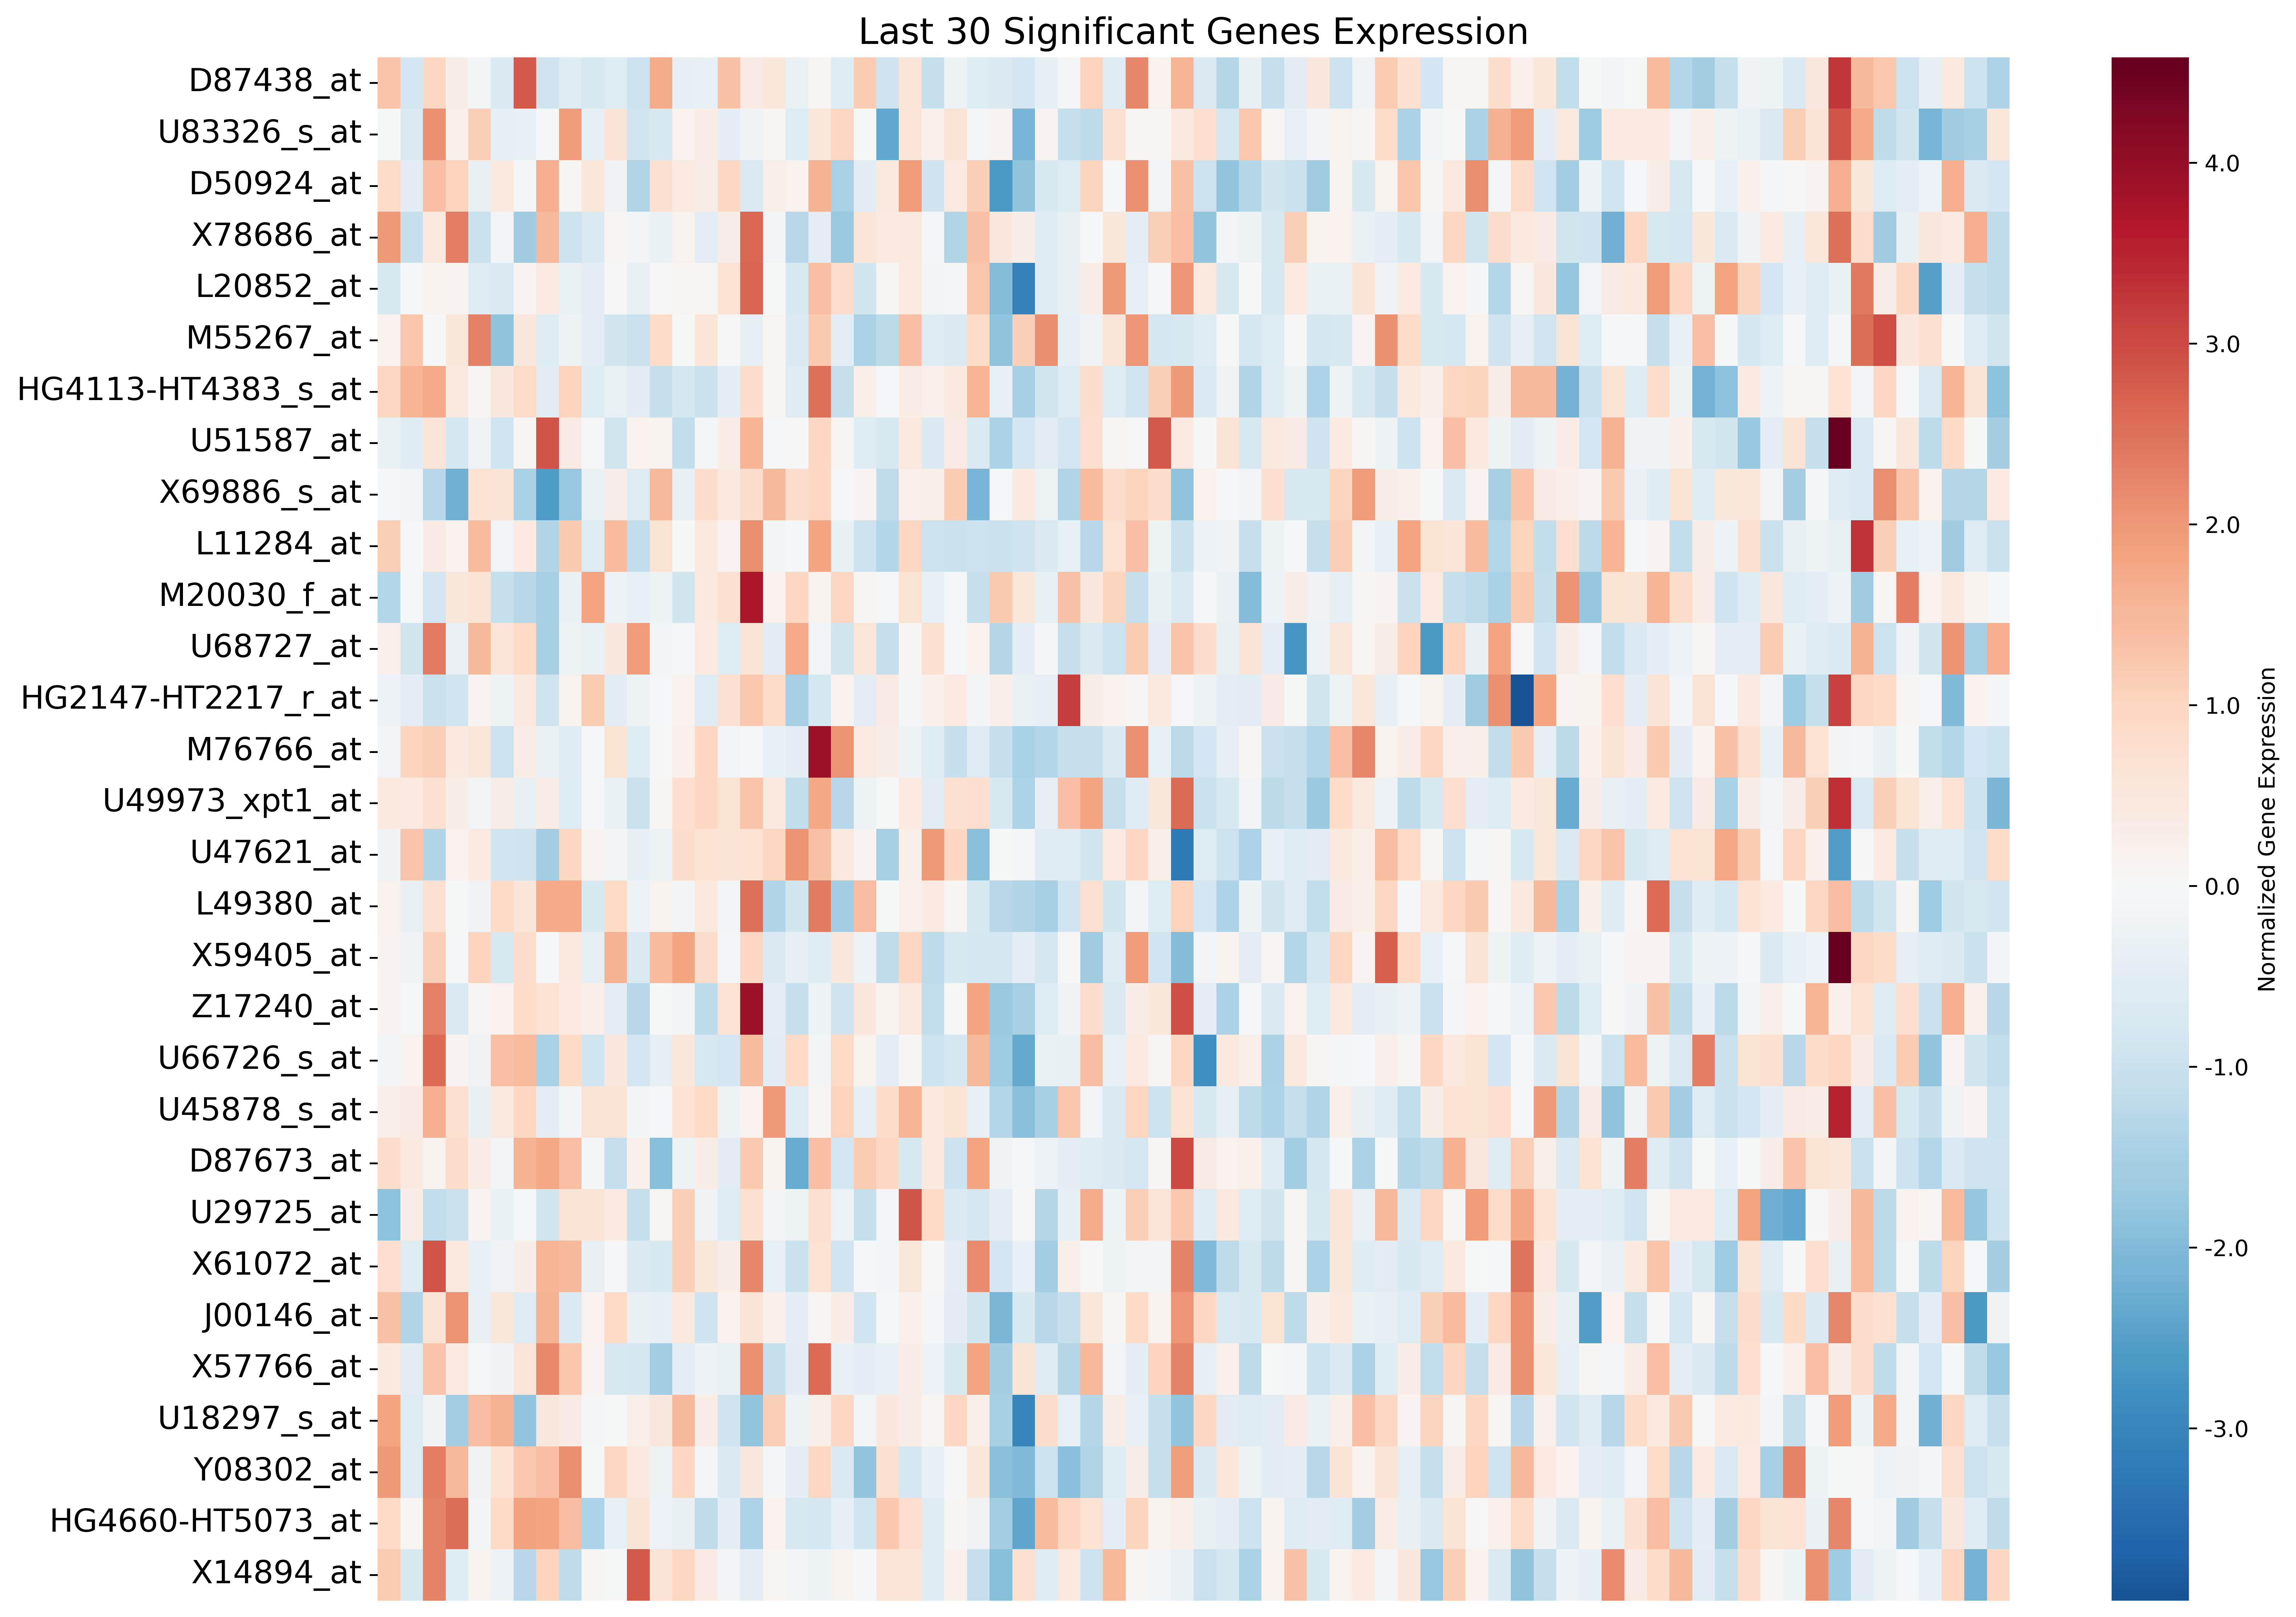

In [83]:
# get the last 30 significant genes
last_genes = ttest_results_sort['Gene Accession Number'].tail(30).tolist()

selected_data = normalized_merged_XY[last_genes]

selected_data['cancer'] = normalized_merged_XY['cancer']

selected_data = selected_data.sort_values('cancer')

plot_data = selected_data.drop('cancer', axis=1).T

plt.figure(figsize=(15, 10), dpi = 450)

sns.heatmap(plot_data,
            cmap='RdBu_r',
            cbar_kws={'label': 'Normalized Gene Expression',
                      'format': '%s'},
            center=0,
            yticklabels=True,
            xticklabels=False)

plt.title('Last 30 Significant Genes Expression',fontsize = 16)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('plt/last30-sig-gene-heatmap.png', dpi=450, bbox_inches='tight')
plt.show()

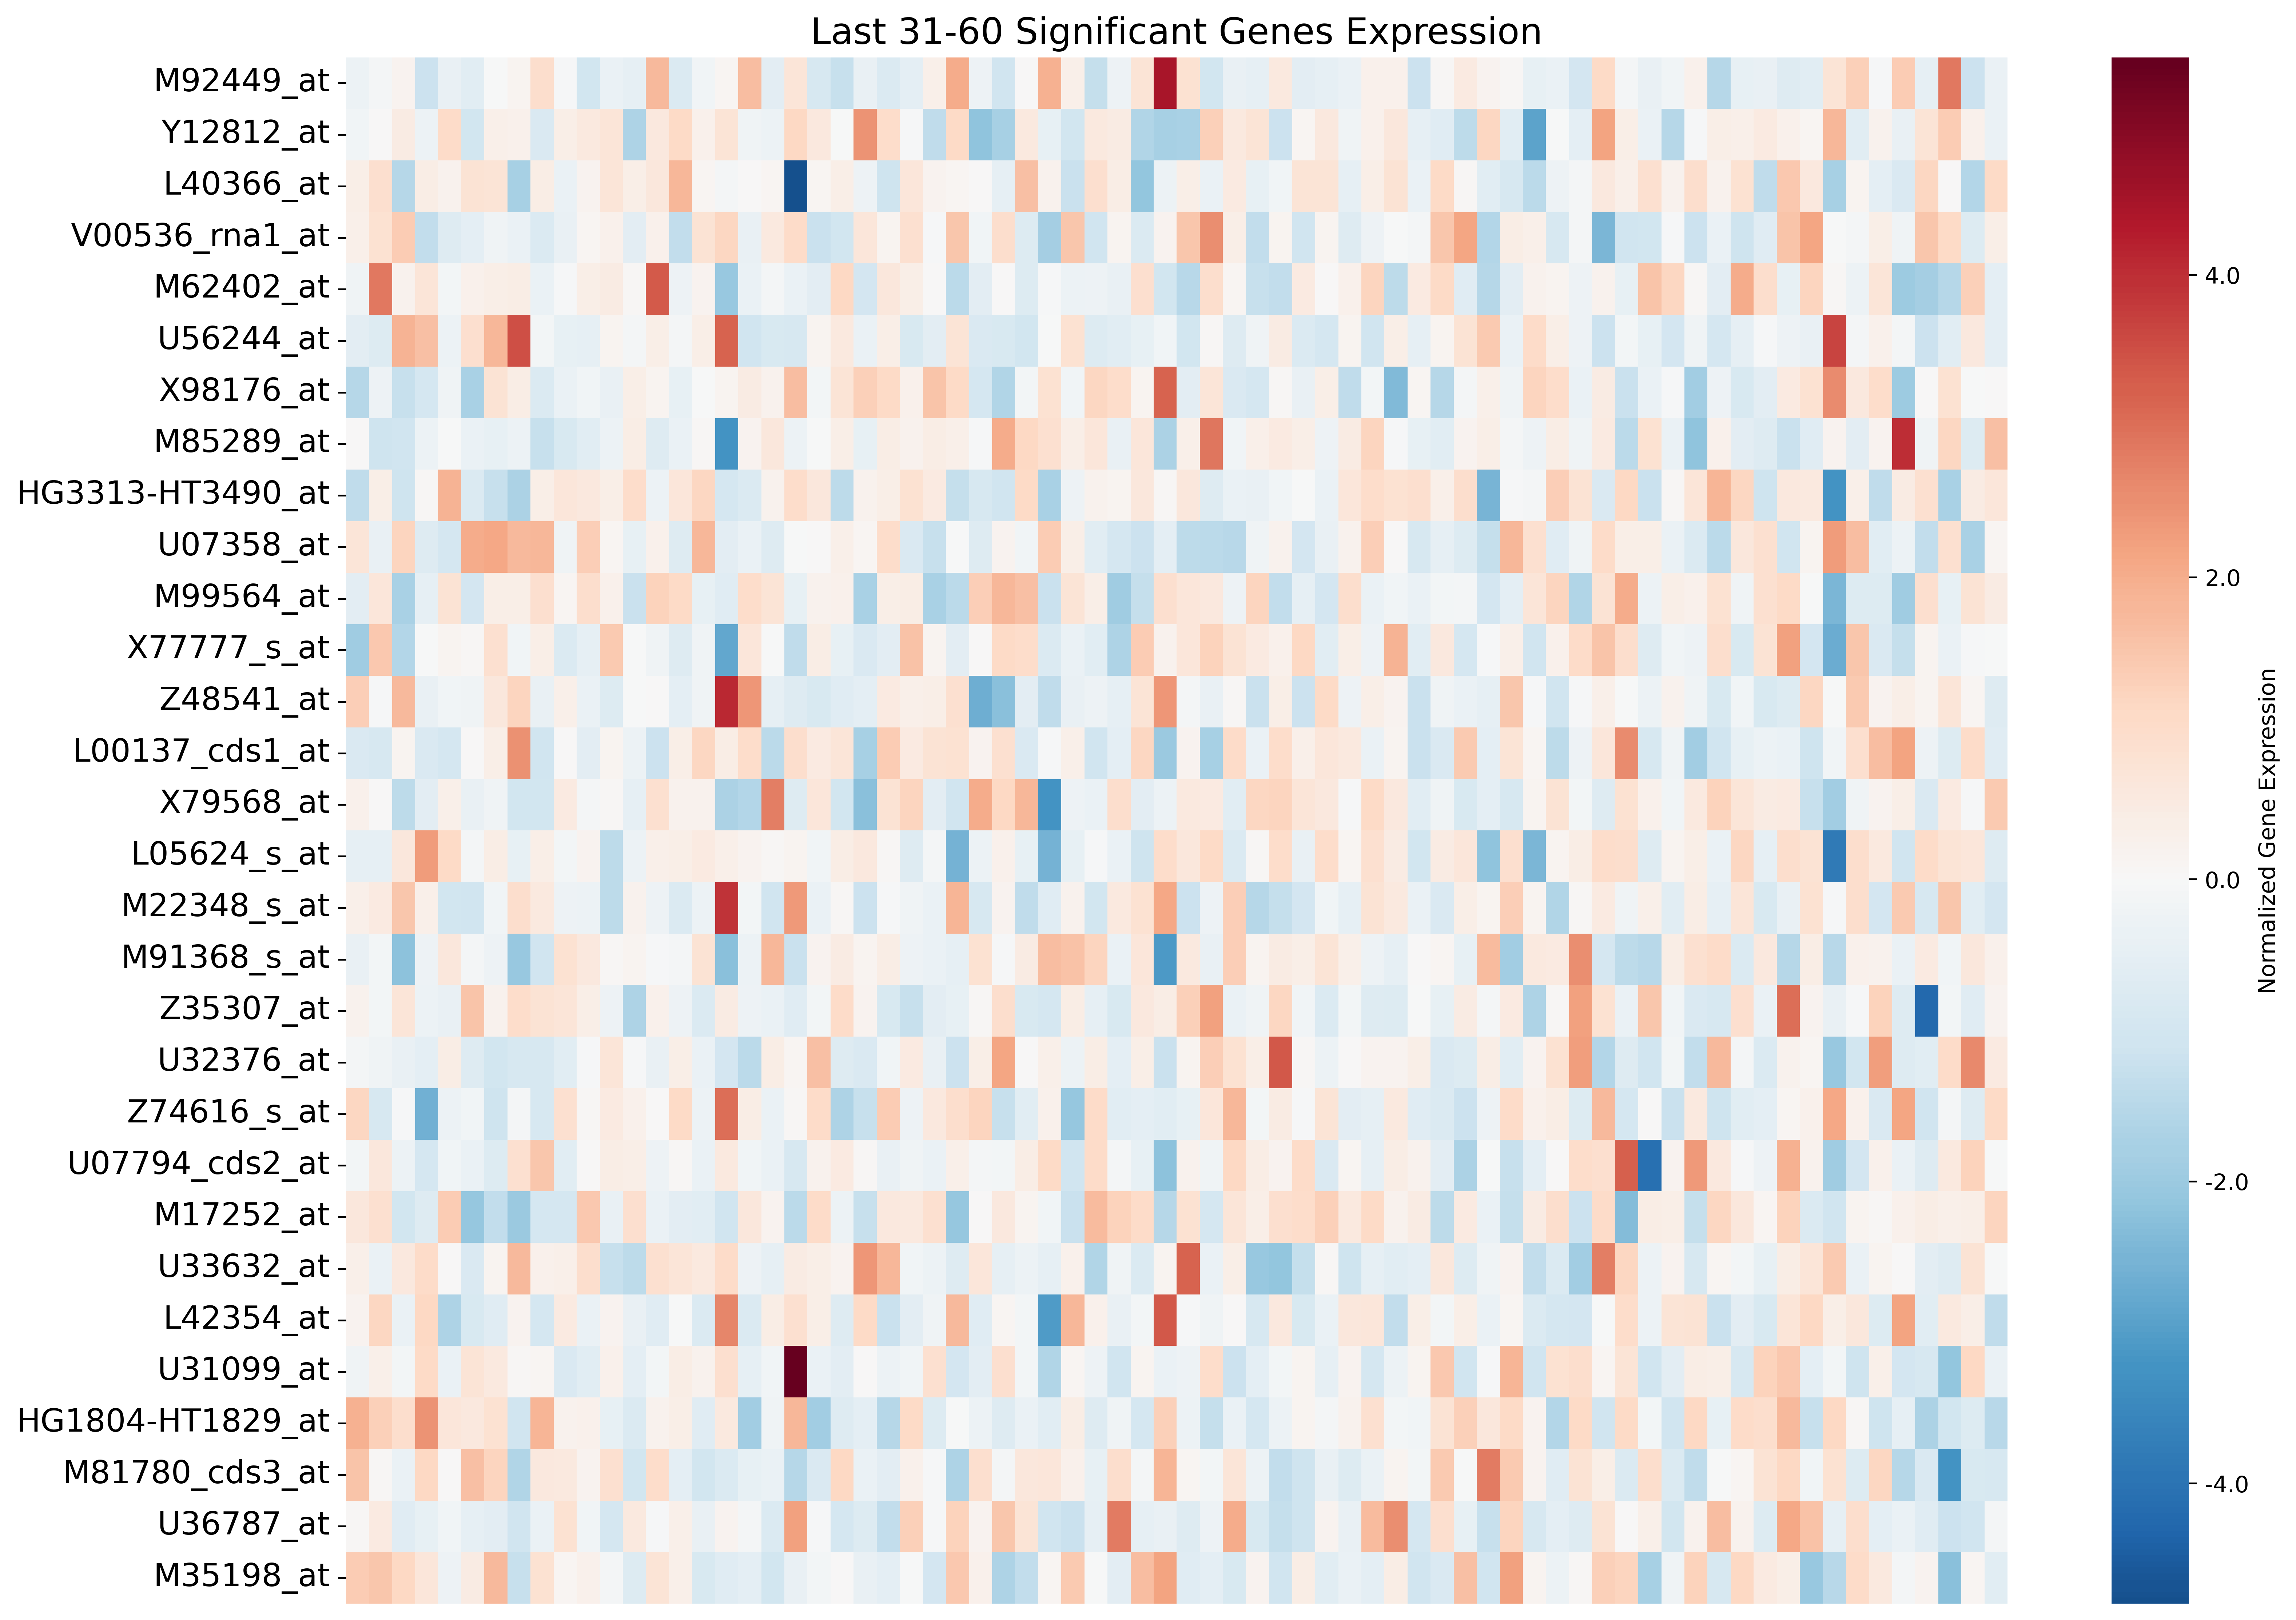

In [84]:
# get the last 31-60 significant genes
last_genes = ttest_results_sort['Gene Accession Number'].iloc[-60:-30].tolist()

selected_data = normalized_merged_XY[last_genes]

selected_data['cancer'] = normalized_merged_XY['cancer']

selected_data = selected_data.sort_values('cancer')

plot_data = selected_data.drop('cancer', axis=1).T

plt.figure(figsize=(15, 10), dpi = 450)

sns.heatmap(plot_data,
            cmap='RdBu_r',
            cbar_kws={'label': 'Normalized Gene Expression',
                      'format': '%s'},
            center=0,
            yticklabels=True,
            xticklabels=False)

plt.title('Last 31-60 Significant Genes Expression',fontsize = 16)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('plt/last60-sig-gene-heatmap.png', dpi=450, bbox_inches='tight')
plt.show()

### **2.2 Regularization**
The t-test only preemptively filters out extremely insignificant variables. However, even after filtering, there are still over 1000 significant variables. Next, we will use regularization methods to further refine the feature selection.

#### **2.2.1 Data Preparation**
Include feature selection and dataset split.

In [86]:
# only significant genes are retained
significant_genes_list = significant_genes['Gene Accession Number'].tolist()
print(f"number of significant genes: {len(significant_genes_list)}")

number of significant genes: 1056


In [87]:
# define feature and target columns
X = normalized_merged_X[significant_genes_list]
y = normalized_merged_XY['cancer']

In [88]:
# divide train and test dataset using an 8:2 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [91]:
print(f"training set shape: {X_train.shape}")
print(f"testing set shape: {X_test.shape}")

training set shape: (57, 1056)
testing set shape: (15, 1056)


#### **2.2.2 Lasso**
**LASSO (Least Absolute Shrinkage and Selection Operator)** achieves feature selection by adding an **L1 regularization** term to the loss function, which compresses the coefficients of unimportant features to zero. Its working mechanism is as follows:

1.   Add the sum of the absolute values ​​of the coefficients as a penalty term to the standard loss function.
2.   The penalty intensity is controlled by adjusting the regularization strength parameter $λ$.
3.   When $λ$ is sufficiently large, some feature coefficients become exactly 0, achieving feature selection.
4.   Features with non-zero coefficients are retained as important variables.

For binary classification problems, the objective function of LASSO logistic regression is:

$
\min_{\beta_0, \boldsymbol{\beta}} \left\{
-\frac{1}{N} \sum_{i=1}^{N} \left[
y_i \log(p(\mathbf{x}_i)) + (1-y_i) \log(1-p(\mathbf{x}_i))
\right]
+ \lambda \sum_{j=1}^{p} |\beta_j|
\right\}
$

Here, the $\mathcal{R}(\boldsymbol{\beta}) = \lambda \sum_{j=1}^{p} |\beta_j|$ is the L1 regularization term (LASSO penalty), which causes the coefficients of unimportant features to become 0, thus achieving feature selection. $λ$ controls the strength of penalty.

In [94]:
# use lasso+logistic+cv to find the best penalty parameter
lasso_logistic_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 3, 500), # searching range of C-value, C-value = 1/lambda
    cv=5,   # five-fold cross-validation
    penalty='l1',
    solver='liblinear',
    random_state=42,
    max_iter=10000
)
lasso_logistic_cv.fit(X_train, y_train)

print(f"Best C-value of Lasso-Logistic: {lasso_logistic_cv.C_[0]:.4f}")
print(f"Number of features selected by Lasso: {sum(lasso_logistic_cv.coef_[0] != 0)}")
print(f"Average accuracy of LASSO cross-validation: {lasso_logistic_cv.scores_[1].mean(axis=0).max():.4f}")

Best C-value of Lasso-Logistic: 0.2403
Number of features selected by Lasso: 14
Average accuracy of LASSO cross-validation: 0.9818


In [100]:
# lasso-logistic evaluation
y_pred = lasso_logistic_cv.predict(X_test)
y_pred_proba = lasso_logistic_cv.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of Lasso-Logistic test set: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy of Lasso-Logistic test set: 0.9333

Classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15


Confusion matrix:
[[10  0]
 [ 1  4]]


In [102]:
# Lasso-Logistic feature selection result
lasso_selected_indices = np.where((lasso_logistic_cv.coef_[0] != 0))[0]
print(f"original numbers of features: {X_train.shape[1]}")
print(f"Number of features selected by Lasso: {len(lasso_selected_indices)}")
print(f"Lasso Feature Selection Ratio: {len(lasso_selected_indices) / X_train.shape[1]:.4%}")

# view the selected features
X_train_lasso = X_train.iloc[:, lasso_selected_indices]
X_test_lasso = X_test.iloc[:, lasso_selected_indices]
print(X_train_lasso.columns)

original numbers of features: 1056
Number of features selected by Lasso: 14
Lasso Feature Selection Ratio: 1.3258%
Index(['HG1612-HT1612_at', 'X95735_at', 'Y07604_at', 'D49950_at',
       'Z14982_rna1_at', 'X63469_at', 'M84526_at', 'Z69881_at',
       'U50136_rna1_at', 'U82759_at', 'M19507_at', 'M96326_rna1_at',
       'X85116_rna1_s_at', 'U37055_rna1_s_at'],
      dtype='object')


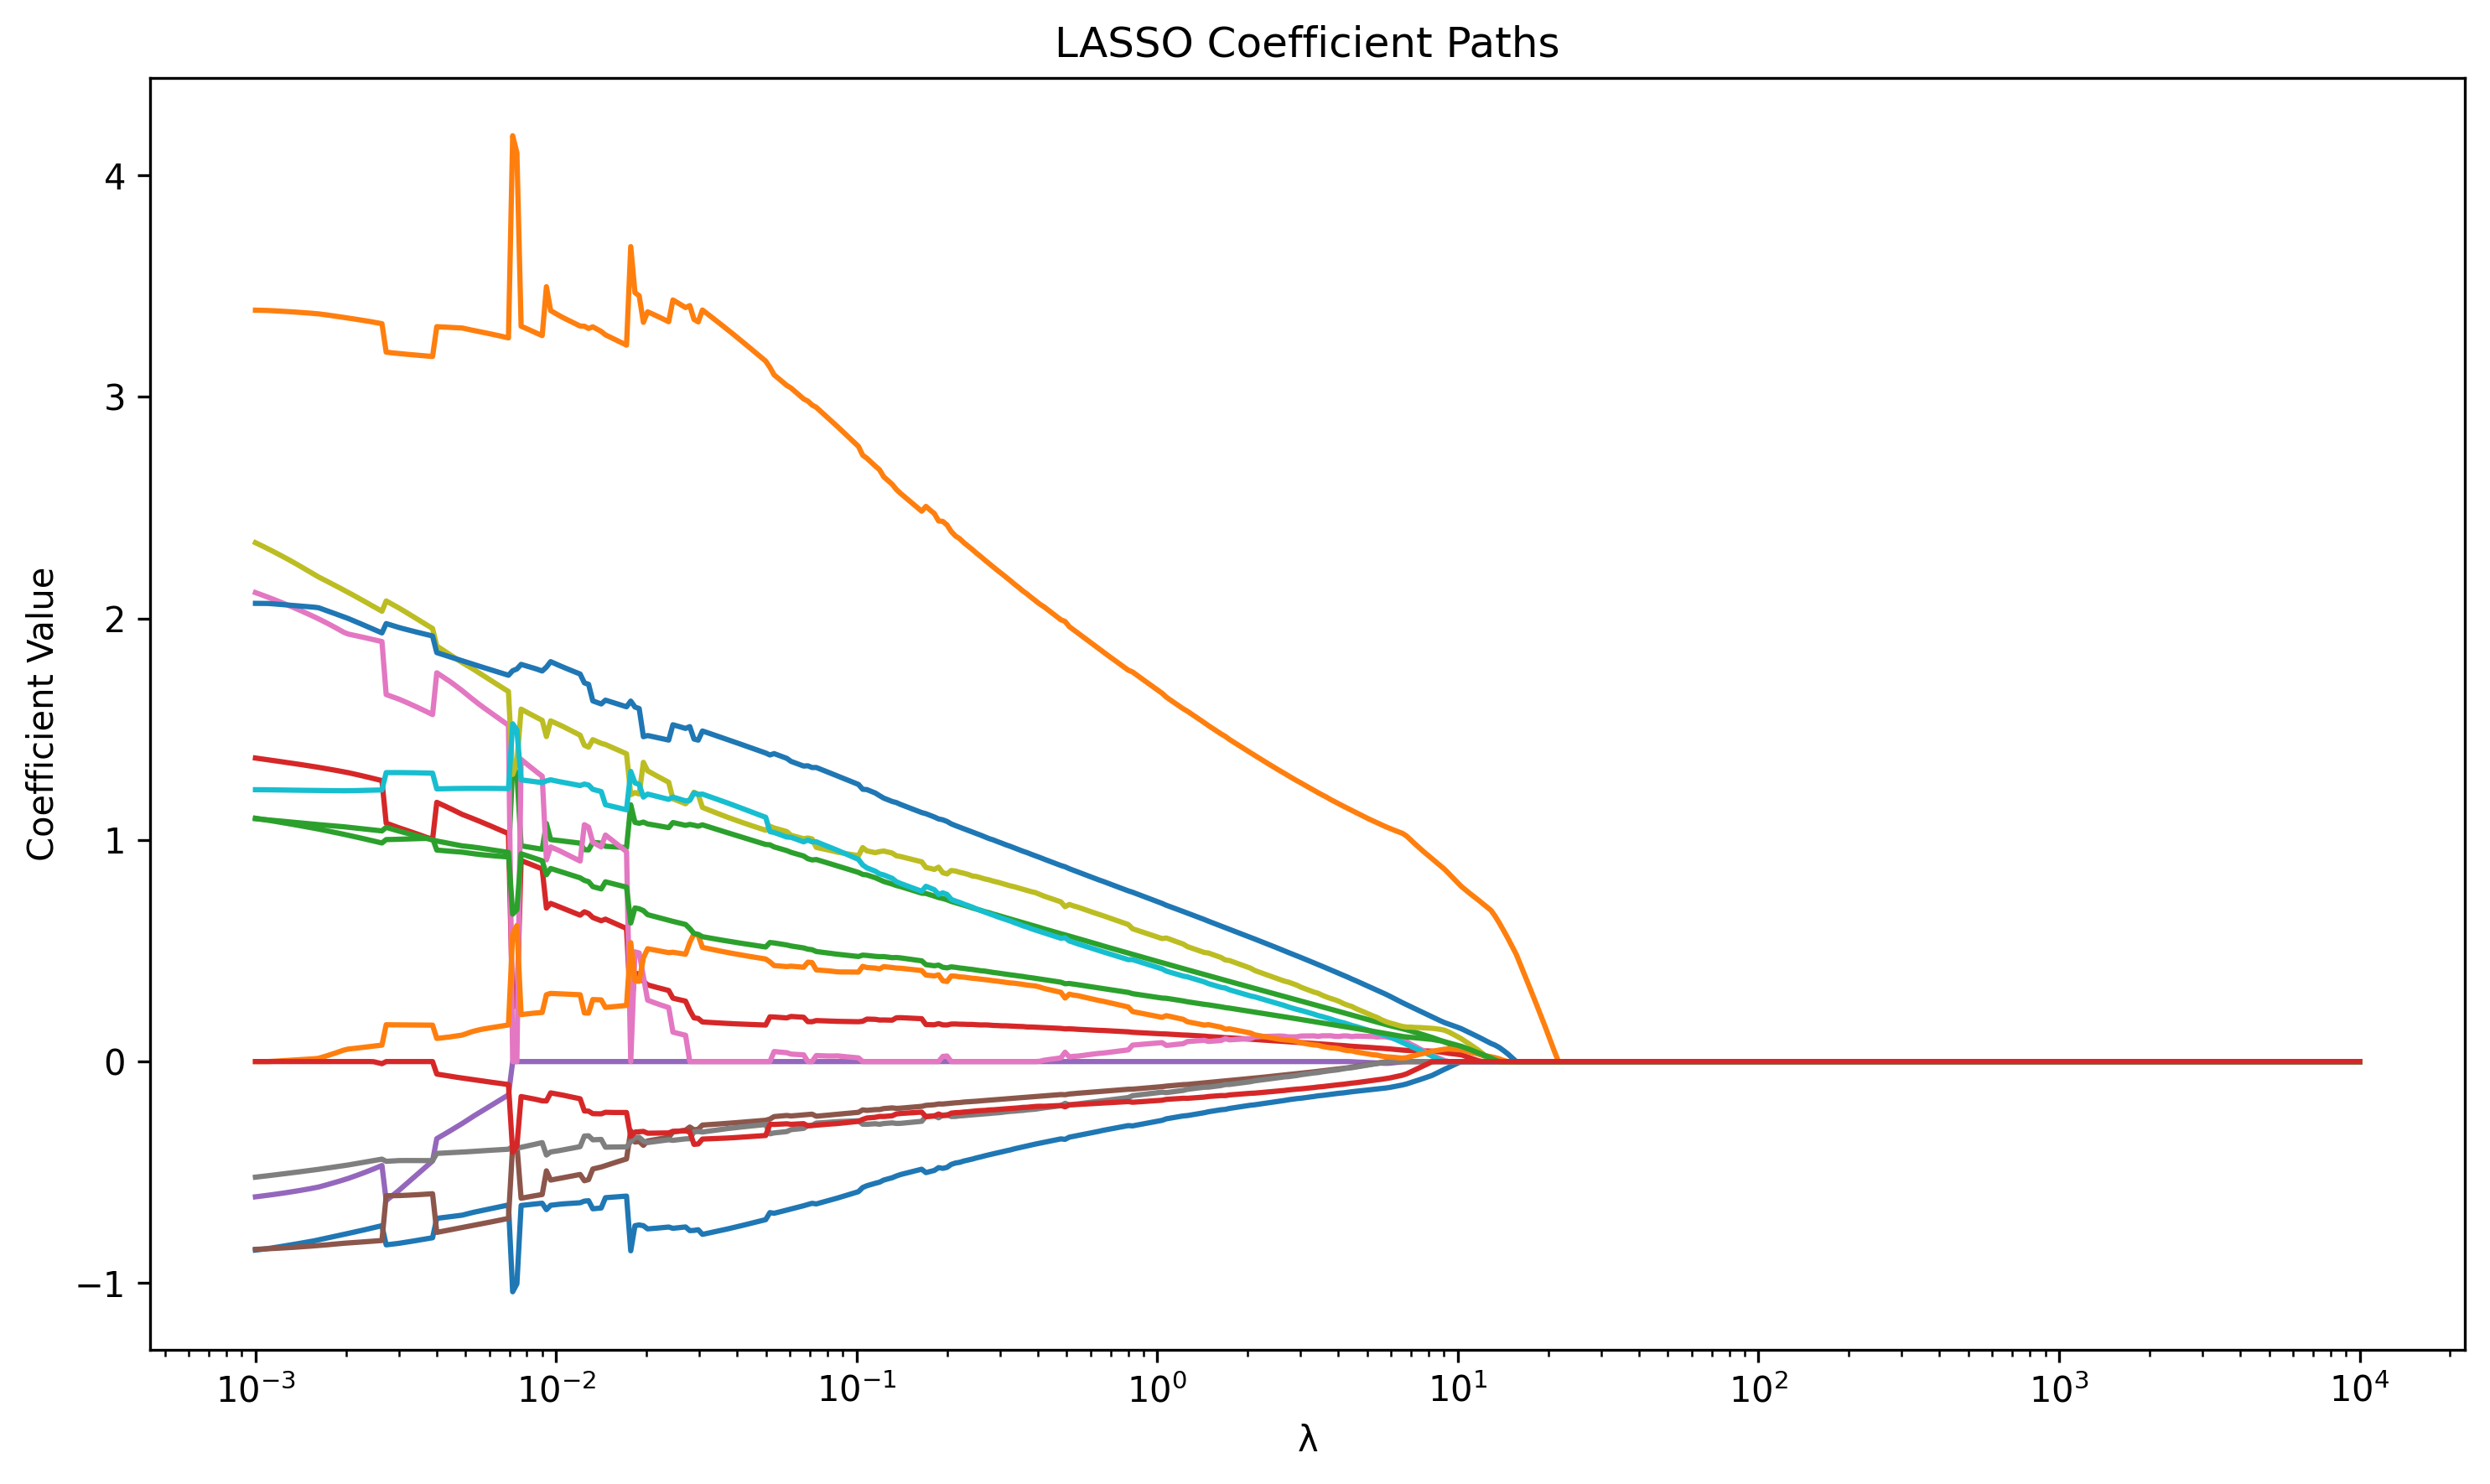

In [112]:
# coefficient paths of Lasso
C_values = np.logspace(-4, 3, 500)
coefs = []

for C in C_values:
    lasso_logistic_cv = LogisticRegression(
        C=C,
        penalty='l1',
        solver='liblinear',
        random_state=42,
        max_iter=10000
        )
    lasso_logistic_cv.fit(X_train_lasso, y_train)
    coefs.append(lasso_logistic_cv.coef_.ravel())

coefs = np.array(coefs)

plt.figure(figsize=(10, 6), dpi = 300)
for i in range(coefs.shape[1]):
    plt.plot(1/ C_values, coefs[:, i], label=f'Feature {i+1}')

plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths')
plt.tight_layout()
plt.savefig('plt/lasso-coefficient-paths.png',dpi = 300, bbox_inches = 'tight')
plt.show()

#### **2.2.3 Ridge**
Ridge Regression controls model complexity and prevents overfitting by adding an L2 regularization term to the loss function, which shrinks coefficients but does not perform feature selection. Its working mechanism is as follows:

1.   Add the sum of the squares of the coefficients as a penalty term to the standard loss function.
2.   The penalty intensity is controlled by adjusting the regularization strength parameter $λ$.
3.   All coefficients are shrunk towards zero but never become exactly zero, so all features are retained.
4.   Features with smaller coefficients have less influence on the prediction.

For binary classification problems, the objective function of Ridge logistic regression is:

$
\min_{\beta_0, \boldsymbol{\beta}} \left\{
-\frac{1}{N} \sum_{i=1}^{N} \left[
y_i \log(p(\mathbf{x}_i)) + (1-y_i) \log(1-p(\mathbf{x}_i))
\right]
+ \lambda \sum_{j=1}^{p} \beta_j^2
\right\}
$

Here, the $\mathcal{R}(\boldsymbol{\beta}) = \lambda \sum_{j=1}^{p} \beta_j^2$ is the L2 regularization term (Ridge penalty), which shrinks coefficients towards zero but never makes them exactly zero. $λ$ controls the strength of penalty.

In [113]:
# use ridge+logistic+cv to find the best penalty parameter
ridge_logistic_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 3, 500),
    cv=5,
    penalty='l2',
    solver='liblinear',
    random_state=42,
    max_iter=10000
)

ridge_logistic_cv.fit(X_train, y_train)

print(f"Best C-value of Ridge-Logistic model: {ridge_logistic_cv.C_[0]:.4f}")
print(f"Average accuracy of Ridge cross-validation: {ridge_logistic_cv.scores_[1].mean(axis=0).max():.4f}")

Best C-value of Ridge-Logistic model: 0.0013
Average accuracy of Ridge cross-validation: 1.0000


In [114]:
# Ridge-Logistic evaluation
y_pred = ridge_logistic_cv.predict(X_test)
y_pred_proba = ridge_logistic_cv.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of ridge-logistic: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy of ridge-logistic: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15


Confusion Matrix:
[[10  0]
 [ 1  4]]


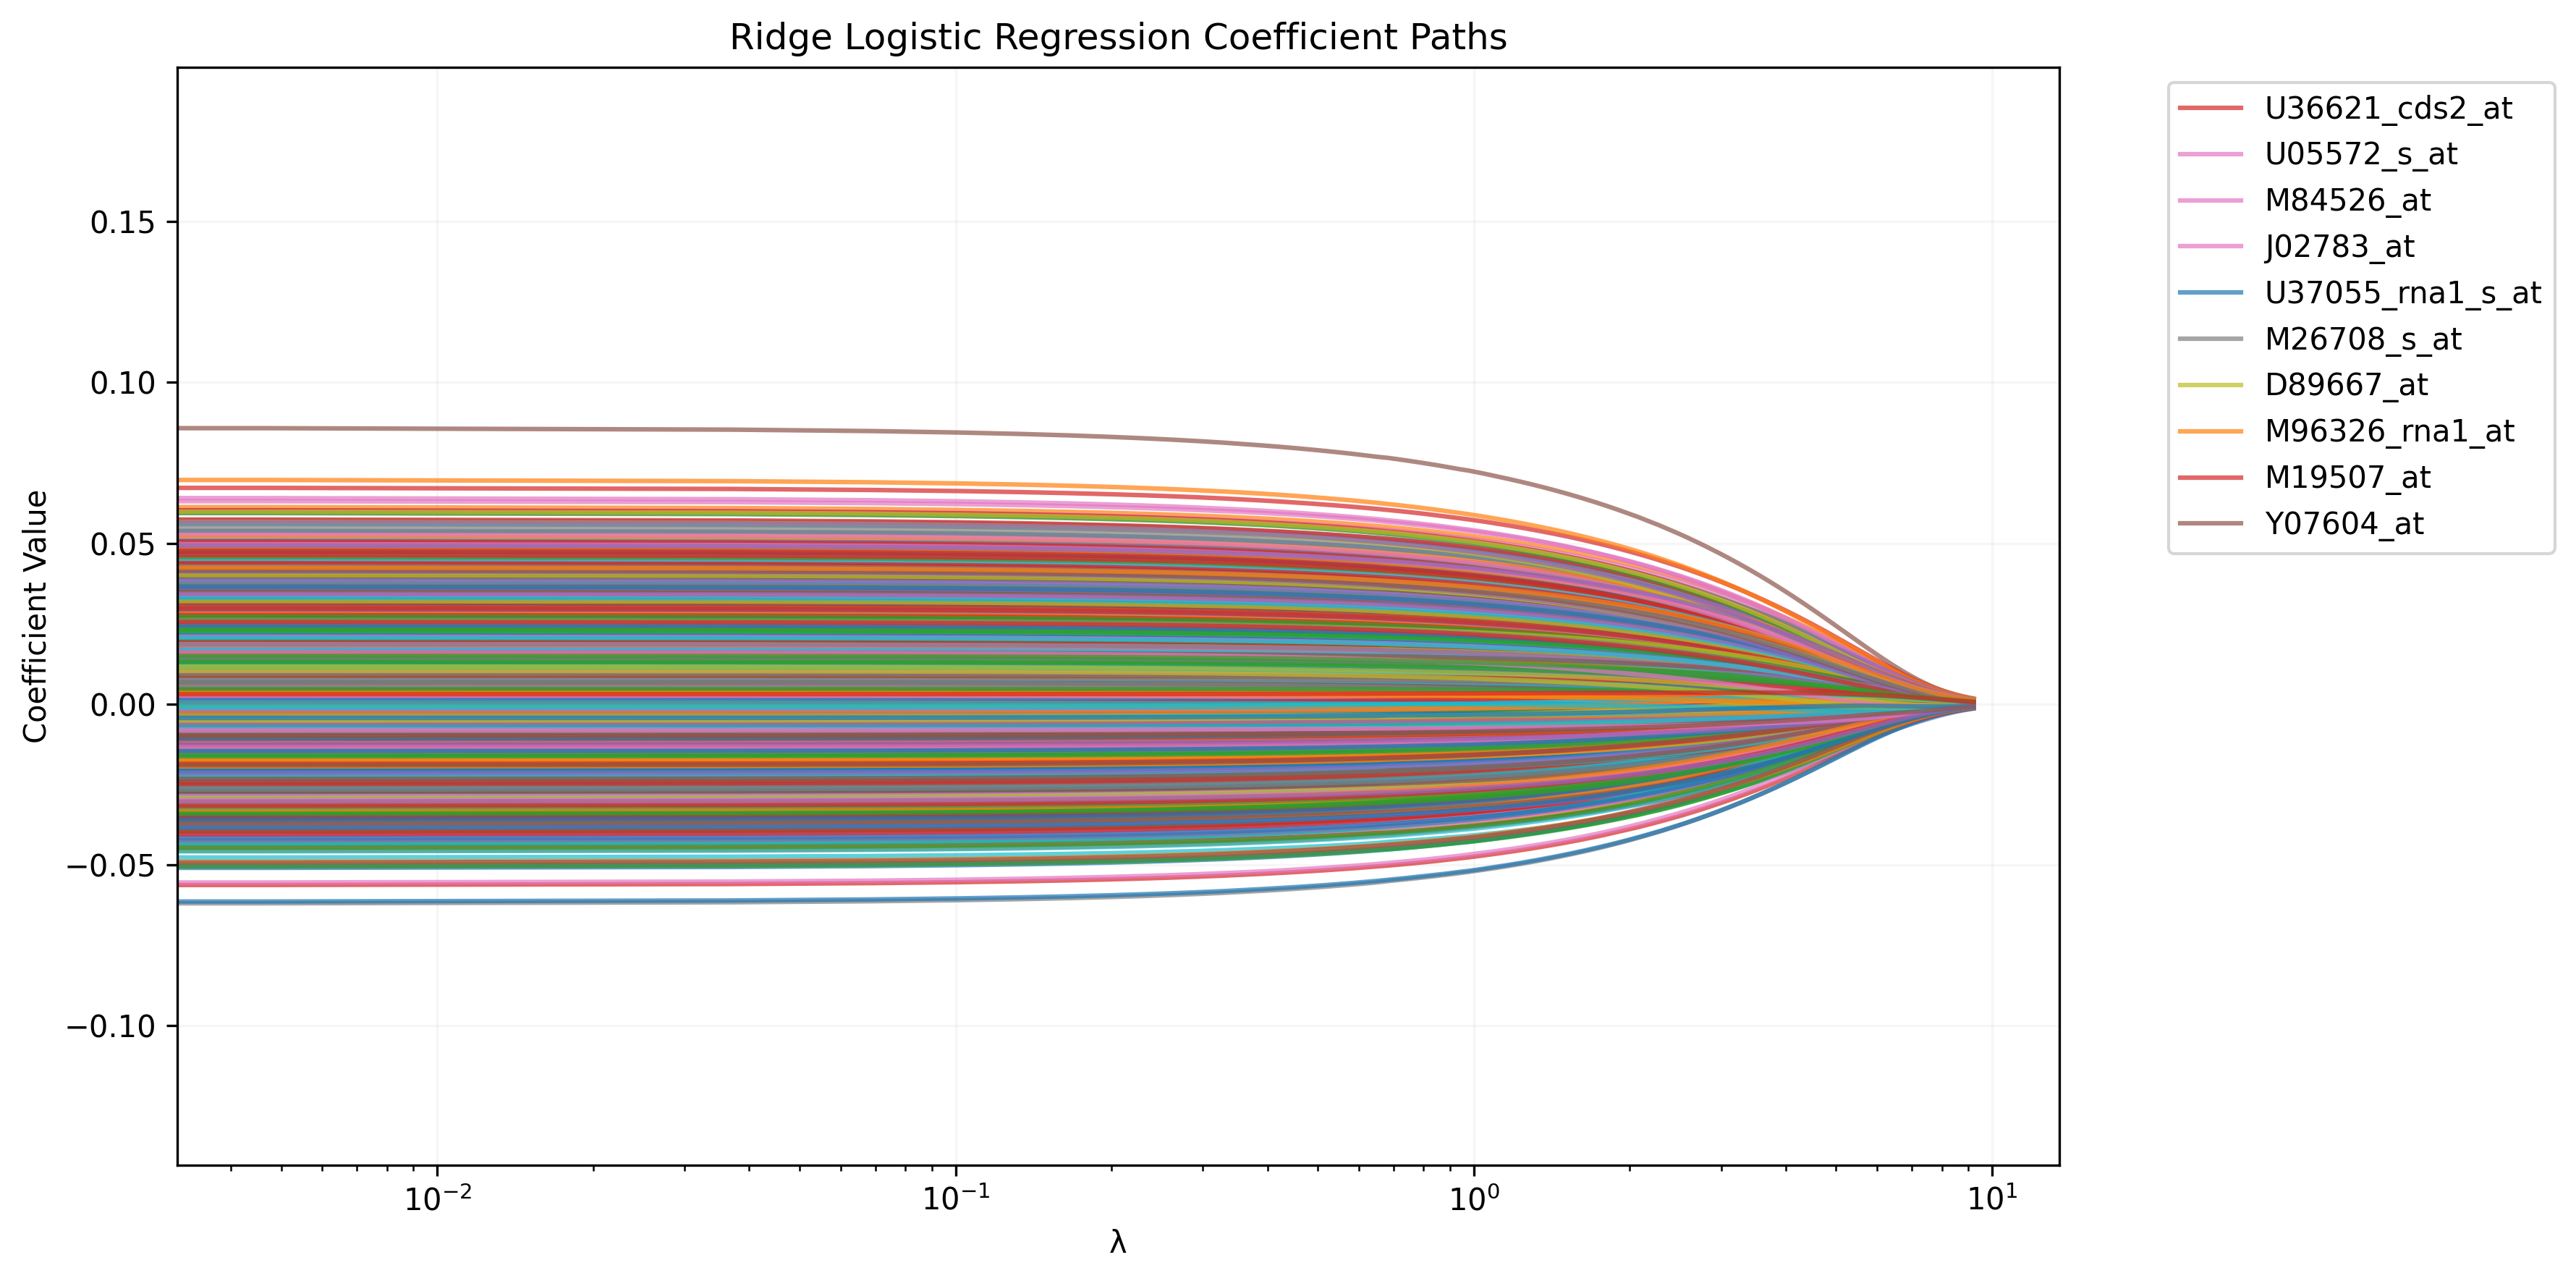

In [125]:
# plot the coeffiecient paths of ridge-logistic
Cs=np.logspace(-4, 3, 500)
coefs_path = []
for C in Cs:
  ridge_logistic_cv = LogisticRegression(
      penalty='l2',
      C=C,
      solver='liblinear',
      random_state=42,
      max_iter=10000
      )
  ridge_logistic_cv.fit(X_train, y_train)
  coefs_path.append(ridge_logistic_cv.coef_.flatten())

coefs_path = np.array(coefs_path)

plt.figure(figsize=(12, 6), dpi = 300)

for i in range(coefs_path.shape[1]):
  if feature_names is not None:
    label = feature_names[i]
  else:
    label = f'Feature {i}'
  plt.plot(-np.log(Cs), coefs_path[:, i], label=label, linewidth=1.5, alpha=0.7)

plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Coefficient Value')
plt.title('Ridge Logistic Regression Coefficient Paths')
plt.grid(True, alpha=0.1)

# only display the top ten legends
best_coefs = ridge_logistic_cv.coef_.flatten()
top_indices = np.argsort(np.abs(best_coefs))[-10:]
handles, labels = plt.gca().get_legend_handles_labels()
top_handles = [handles[i] for i in top_indices if i < len(handles)]
top_labels = [labels[i] for i in top_indices if i < len(labels)]
plt.legend(top_handles, top_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plt/ridge-coefficient-paths.png',dpi = 300, bbox_inches = 'tight')
plt.show()

#### **2.2.4 ElasticNet**
Elastic Net combines both L1 and L2 regularization methods, aiming to leverage the advantages of both LASSO and Ridge regression. Its working mechanism is as follows:

1. Add a linear combination of L1 and L2 penalty terms to the standard loss function.
2. The overall penalty intensity is controlled by parameter $λ$, while the mix ratio between L1 and L2 is controlled by parameter $α$.
3. When $α = 1$, Elastic Net is equivalent to LASSO; when $α = 0$, it is equivalent to Ridge.
4. Elastic Net can select groups of correlated features and is more stable than LASSO when features are highly correlated.

For binary classification problems, the objective function of Elastic Net logistic regression is:

$
\min_{\beta_0, \boldsymbol{\beta}} \left\{
-\frac{1}{N} \sum_{i=1}^{N} \left[
y_i \log(p(\mathbf{x}_i)) + (1-y_i) \log(1-p(\mathbf{x}_i))
\right]
+ \lambda ( \alpha \sum_{j=1}^{p} |\beta_j| + \frac{1-\alpha}{2} \sum_{j=1}^{p} \beta_j^2 )
\right\}
$

Here, the $\mathcal{R}(\boldsymbol{\beta}) = \lambda \left( \alpha \sum_{j=1}^{p} |\beta_j| + \frac{1-\alpha}{2} \sum_{j=1}^{p} \beta_j^2 \right)$ is the Elastic Net regularization term, which combines both L1 and L2 penalties. $λ$ controls the overall strength of penalty, while $α$ controls the mix ratio between L1 and L2 regularization.

l1_ratio: 0.1, Best C: 0.035112, Selected features: 215, CV Acc: 0.8767, Test Acc: 0.9333
l1_ratio: 0.2, Best C: 0.079248, Selected features: 128, CV Acc: 0.8630, Test Acc: 0.9333
l1_ratio: 0.3, Best C: 0.151991, Selected features: 105, CV Acc: 0.8545, Test Acc: 0.9333
l1_ratio: 0.4, Best C: 0.247708, Selected features: 98, CV Acc: 0.8482, Test Acc: 0.9333
l1_ratio: 0.5, Best C: 0.403702, Selected features: 89, CV Acc: 0.8430, Test Acc: 0.9333
l1_ratio: 0.6, Best C: 0.657933, Selected features: 96, CV Acc: 0.8381, Test Acc: 0.9333
l1_ratio: 0.7, Best C: 1.072267, Selected features: 105, CV Acc: 0.8336, Test Acc: 0.9333
l1_ratio: 0.8, Best C: 2.056512, Selected features: 165, CV Acc: 0.8294, Test Acc: 0.9333
l1_ratio: 0.9, Best C: 3.944206, Selected features: 296, CV Acc: 0.8256, Test Acc: 0.9333


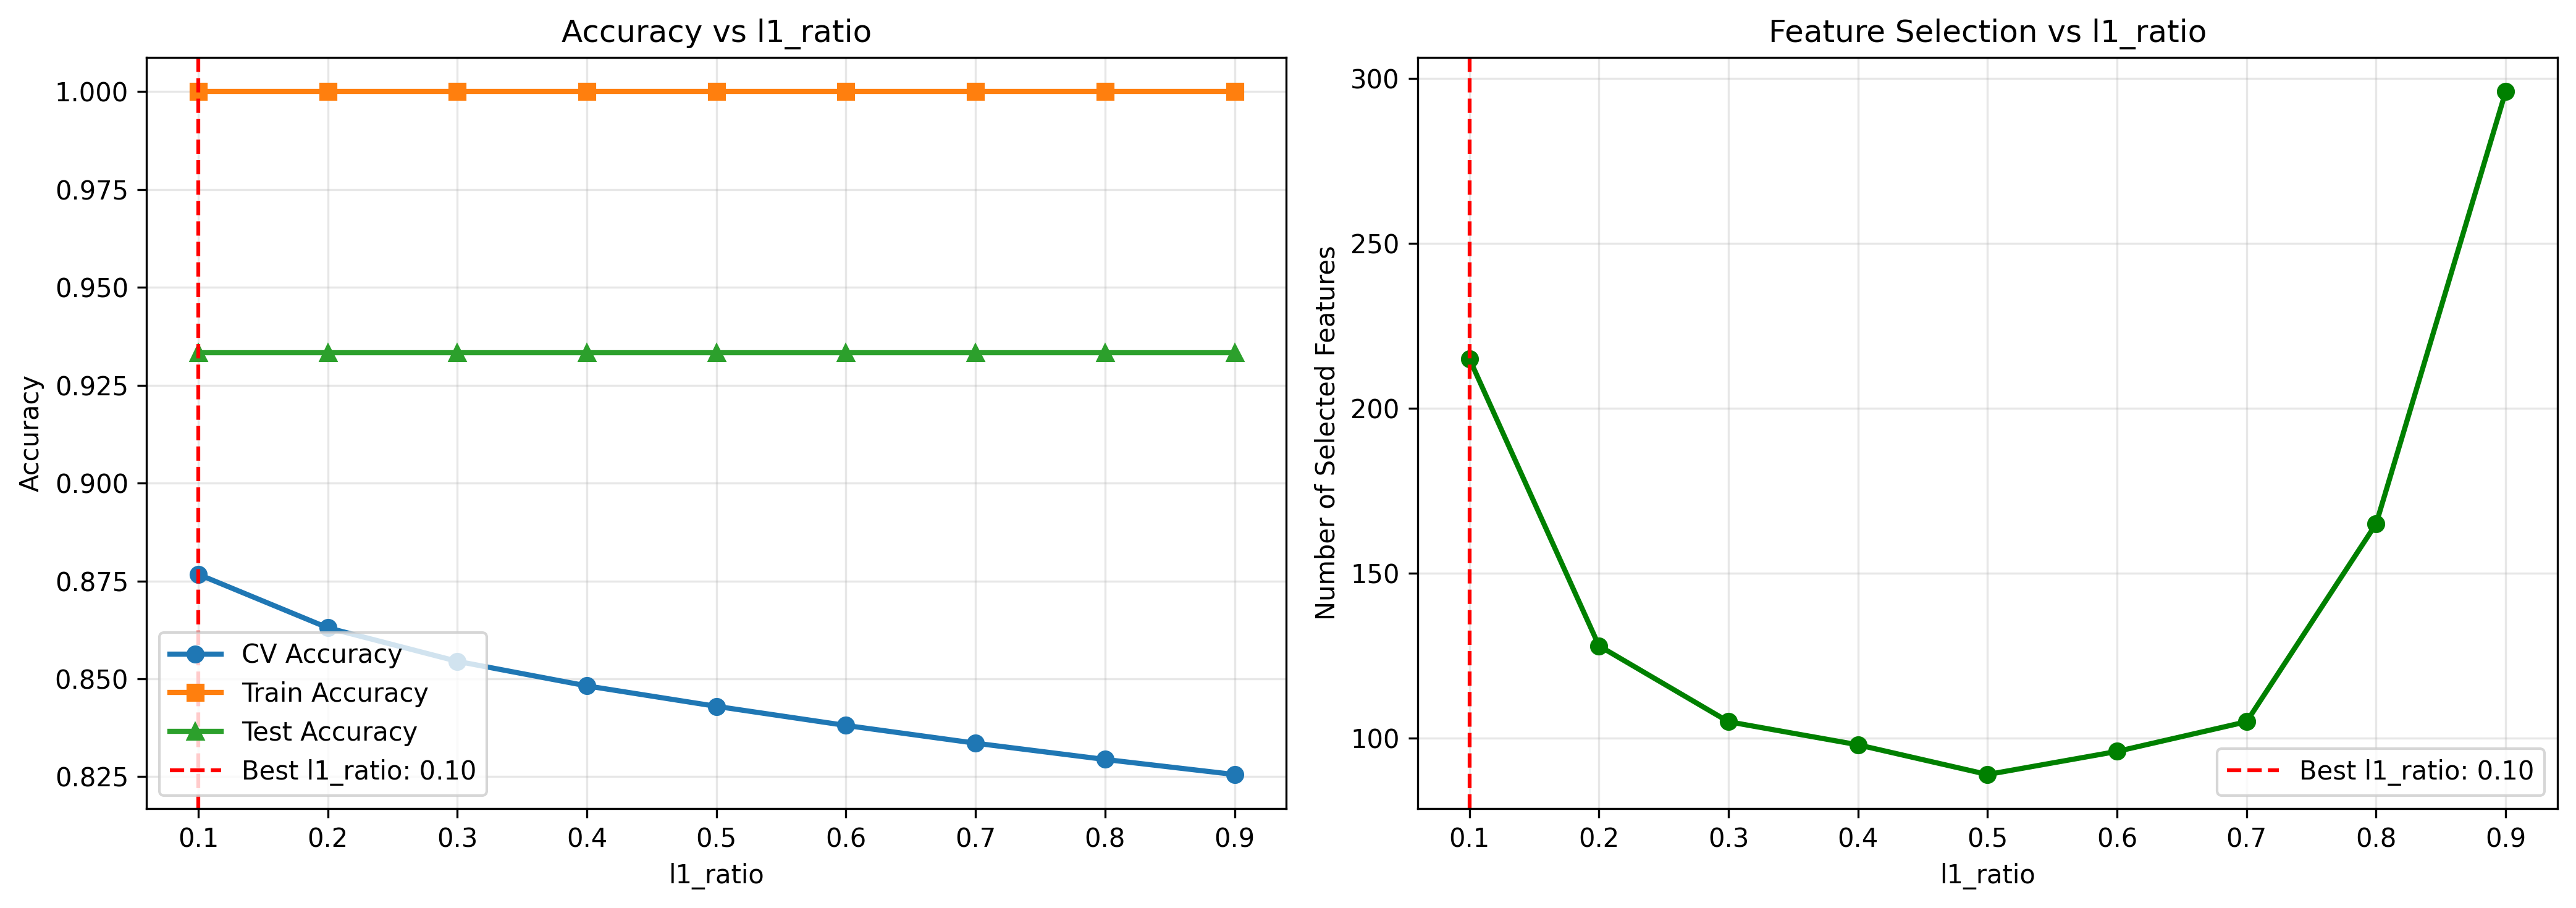


整体最佳模型参数:
  最佳l1_ratio: 0.1000
  对应的最佳C值: 0.035112
  选择的特征数量: 215
  训练集准确率: 1.0000
  测试集准确率: 0.9333


In [141]:
l1_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
cv_accuracies = []
train_accuracies = []
test_accuracies = []
selected_features_count = []
best_Cs = []

for l1_ratio in l1_ratios:
    elasticnet_cv = LogisticRegressionCV(
        Cs=np.logspace(-4, 3, 100),
        cv=5,
        l1_ratios=[l1_ratio],
        penalty='elasticnet',
        solver='saga',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    elasticnet_cv.fit(X_train, y_train)

    # get the best C-value
    best_C = float(elasticnet_cv.C_[0])
    best_Cs.append(best_C)
    best_model = elasticnet_cv

    # record the metrics
    cv_acc = np.mean(best_model.scores_[1].mean(axis=0))
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)

    cv_accuracies.append(cv_acc)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # record number of selected features
    n_selected = np.sum(best_model.coef_[0] != 0)
    selected_features_count.append(n_selected)

    print(f"l1_ratio: {l1_ratio:.1f}, Best C: {best_C:.6f}, Selected features: {n_selected}, "
          f"CV Acc: {cv_acc:.4f}, Test Acc: {test_acc:.4f}")

# Find the overall optimal l1_ratio
best_overall_idx = np.argmax(test_accuracies)
best_overall_l1_ratio = l1_ratios[best_overall_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Accuracy as a function of l1_ratio
ax1.plot(l1_ratios, cv_accuracies, 'o-', label='CV Accuracy', linewidth=2)
ax1.plot(l1_ratios, train_accuracies, 's-', label='Train Accuracy', linewidth=2)
ax1.plot(l1_ratios, test_accuracies, '^-', label='Test Accuracy', linewidth=2)
ax1.axvline(best_overall_l1_ratio, color='red', linestyle='--',
           label=f'Best l1_ratio: {best_overall_l1_ratio:.2f}')
ax1.set_xlabel('l1_ratio')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs l1_ratio')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Number of selected features as l1_ratio
ax2.plot(l1_ratios, selected_features_count, 'o-', color='green', linewidth=2)
ax2.axvline(best_overall_l1_ratio, color='red', linestyle='--',
           label=f'Best l1_ratio: {best_overall_l1_ratio:.2f}')
ax2.set_xlabel('l1_ratio')
ax2.set_ylabel('Number of Selected Features')
ax2.set_title('Feature Selection vs l1_ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plt/elasticnet-logistic-result-visualization.png', dpi=300,
            bbox_inches='tight')
plt.show()

# the overall best model
print(f"Best l1_ratio of elasticnet-logistic: {best_overall_l1_ratio:.4f}")
print(f"Best C-value of elasticnet-logistic: {best_Cs[best_overall_idx]:.4f}")
print(f"Number of selected features of elasticnet-logistic: {selected_features_count[best_overall_idx]}")
print(f"Accuracy on training set of elasticnet-logistic: {train_accuracies[best_overall_idx]:.4f}")
print(f"Accuracy on testing set of elasticnet-logistic: {test_accuracies[best_overall_idx]:.4f}")

In fact, the results of Elasticnet-Logistic are somewhat counterintuitive:
First, as the l1 ratio increases, the coefficient compression capability of the Elasticnet gradually increases, and theoretically the number of features should decrease. However, the results show an inverted U-shaped pattern. This may be because the optimal C value changes with the l1 ratio, affecting feature selection.

Second, the model performance does not change significantly with the l1 ratio. This is presumably because the sample size is too small, the dataset is relatively simple, and there is almost no room for improvement in model performance.

## **3. Further Analysis**
The above describes classification using a logistic regression model. Next, we'll try other machine learning models to capture more complex interaction effects and observe whether the model accuracy improves further.

### **3.1 Random Forest**

Best parameter of RF: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
Best accuracy of RF: 0.9652
Accuracy on testing set of Lasso-RF: 0.9333


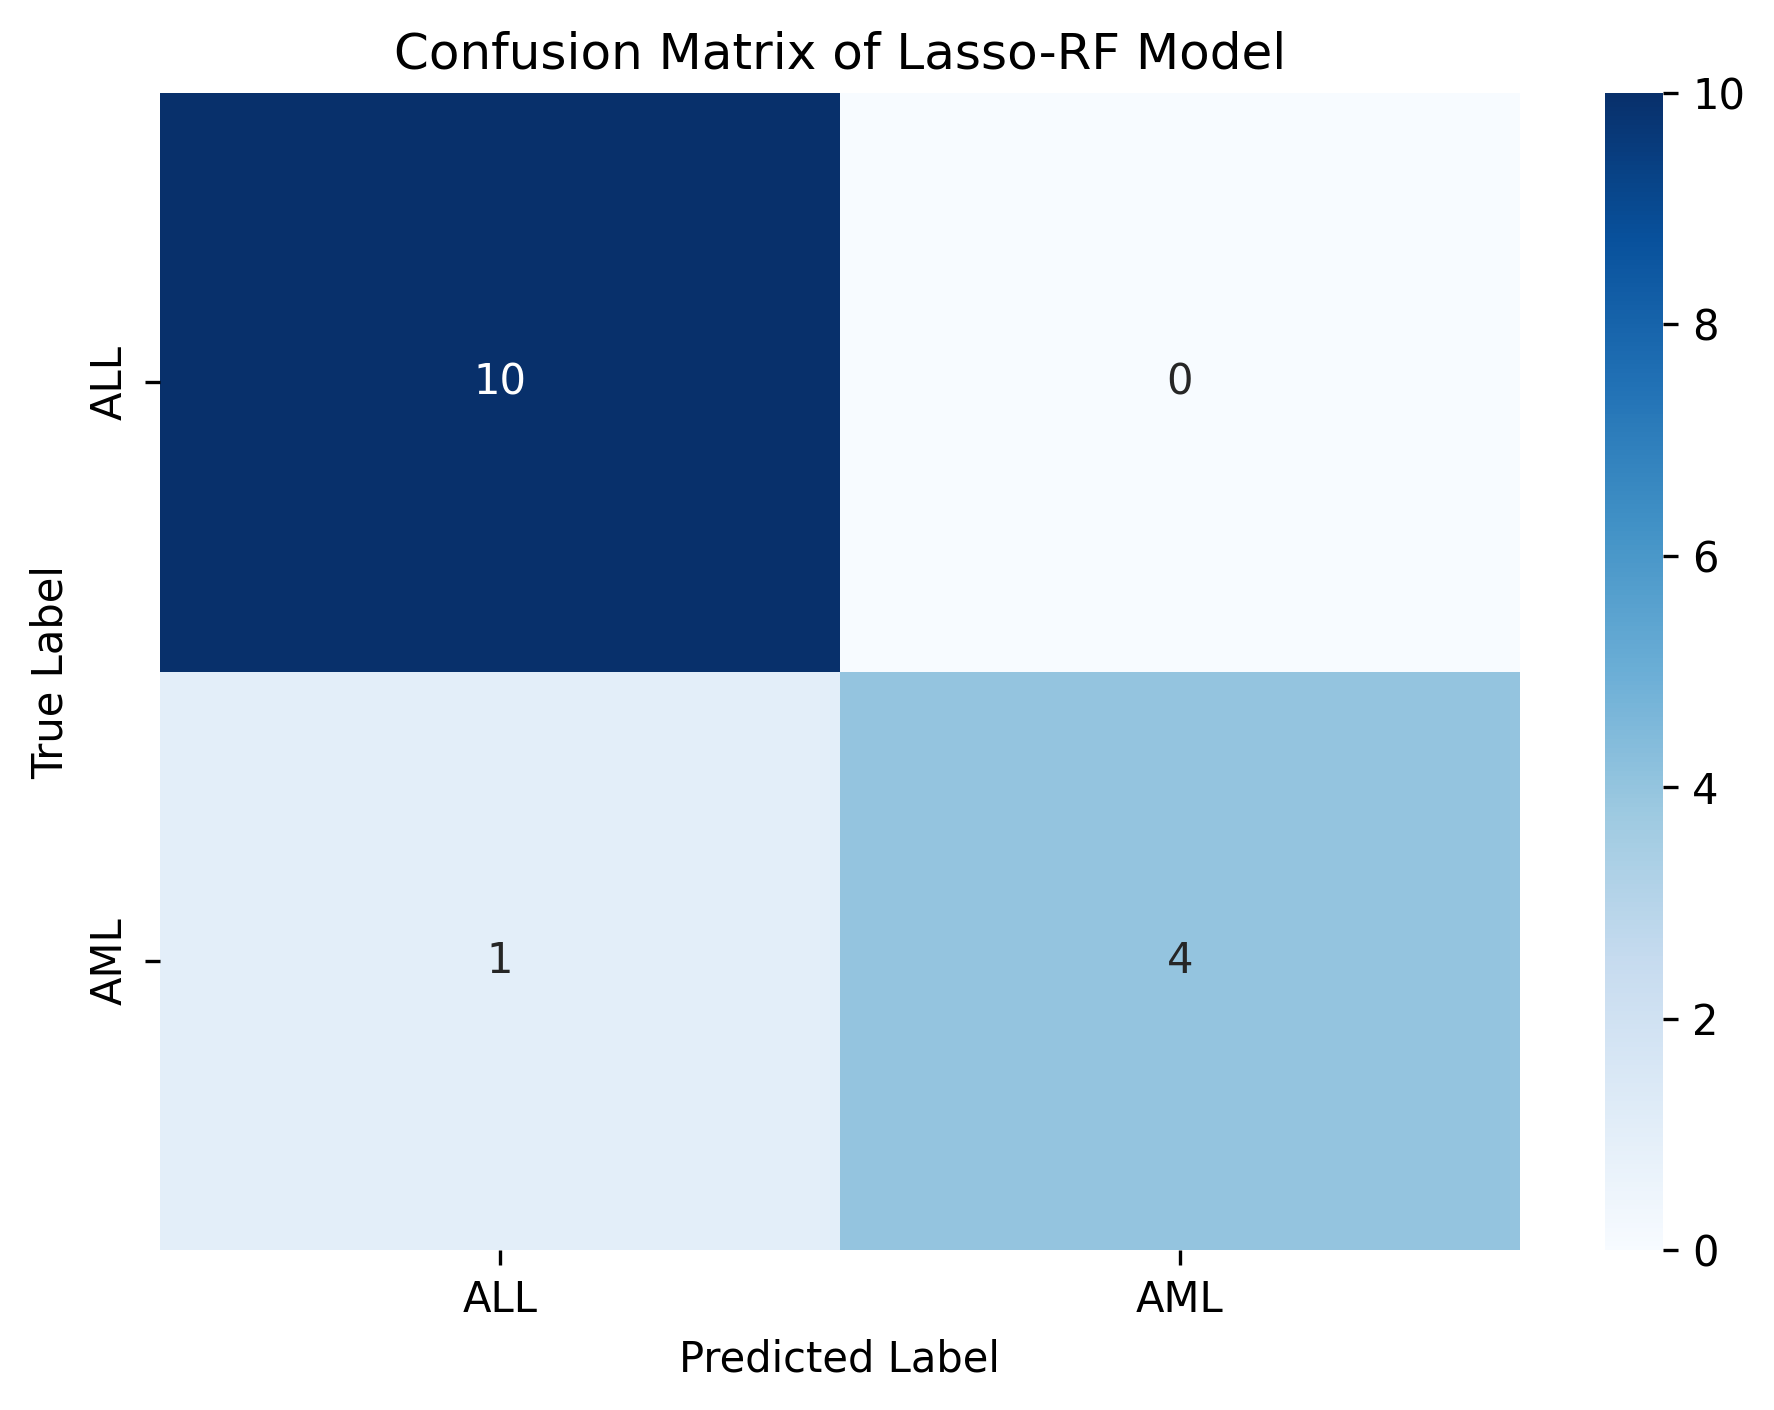

In [144]:
# train RF model through gridsearch
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5],
    'max_features': ['sqrt', 0.5]
}

rf = RandomForestClassifier(random_state=42)
grid_rf_lasso = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf_lasso.fit(X_train_lasso, y_train)

print(f"Best parameter of RF: {grid_rf_lasso.best_params_}")
print(f"Best accuracy of RF: {grid_rf_lasso.best_score_:.4f}")

y_pred = grid_rf_lasso.predict(X_test_lasso)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on testing set of Lasso-RF: {accuracy:.4f}")

plt.figure(dpi = 300)
cm = confusion_matrix(y_test, y_pred)

labels = ['ALL', 'AML']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix of Lasso-RF Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plt/lasso-rf-confusion-matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

### **3.2 SVM**

Best parameter of Lasso-SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best accuracy of Lasso-SVM: 1.0000
Best accuracy of Lasso-SVM: 0.8667


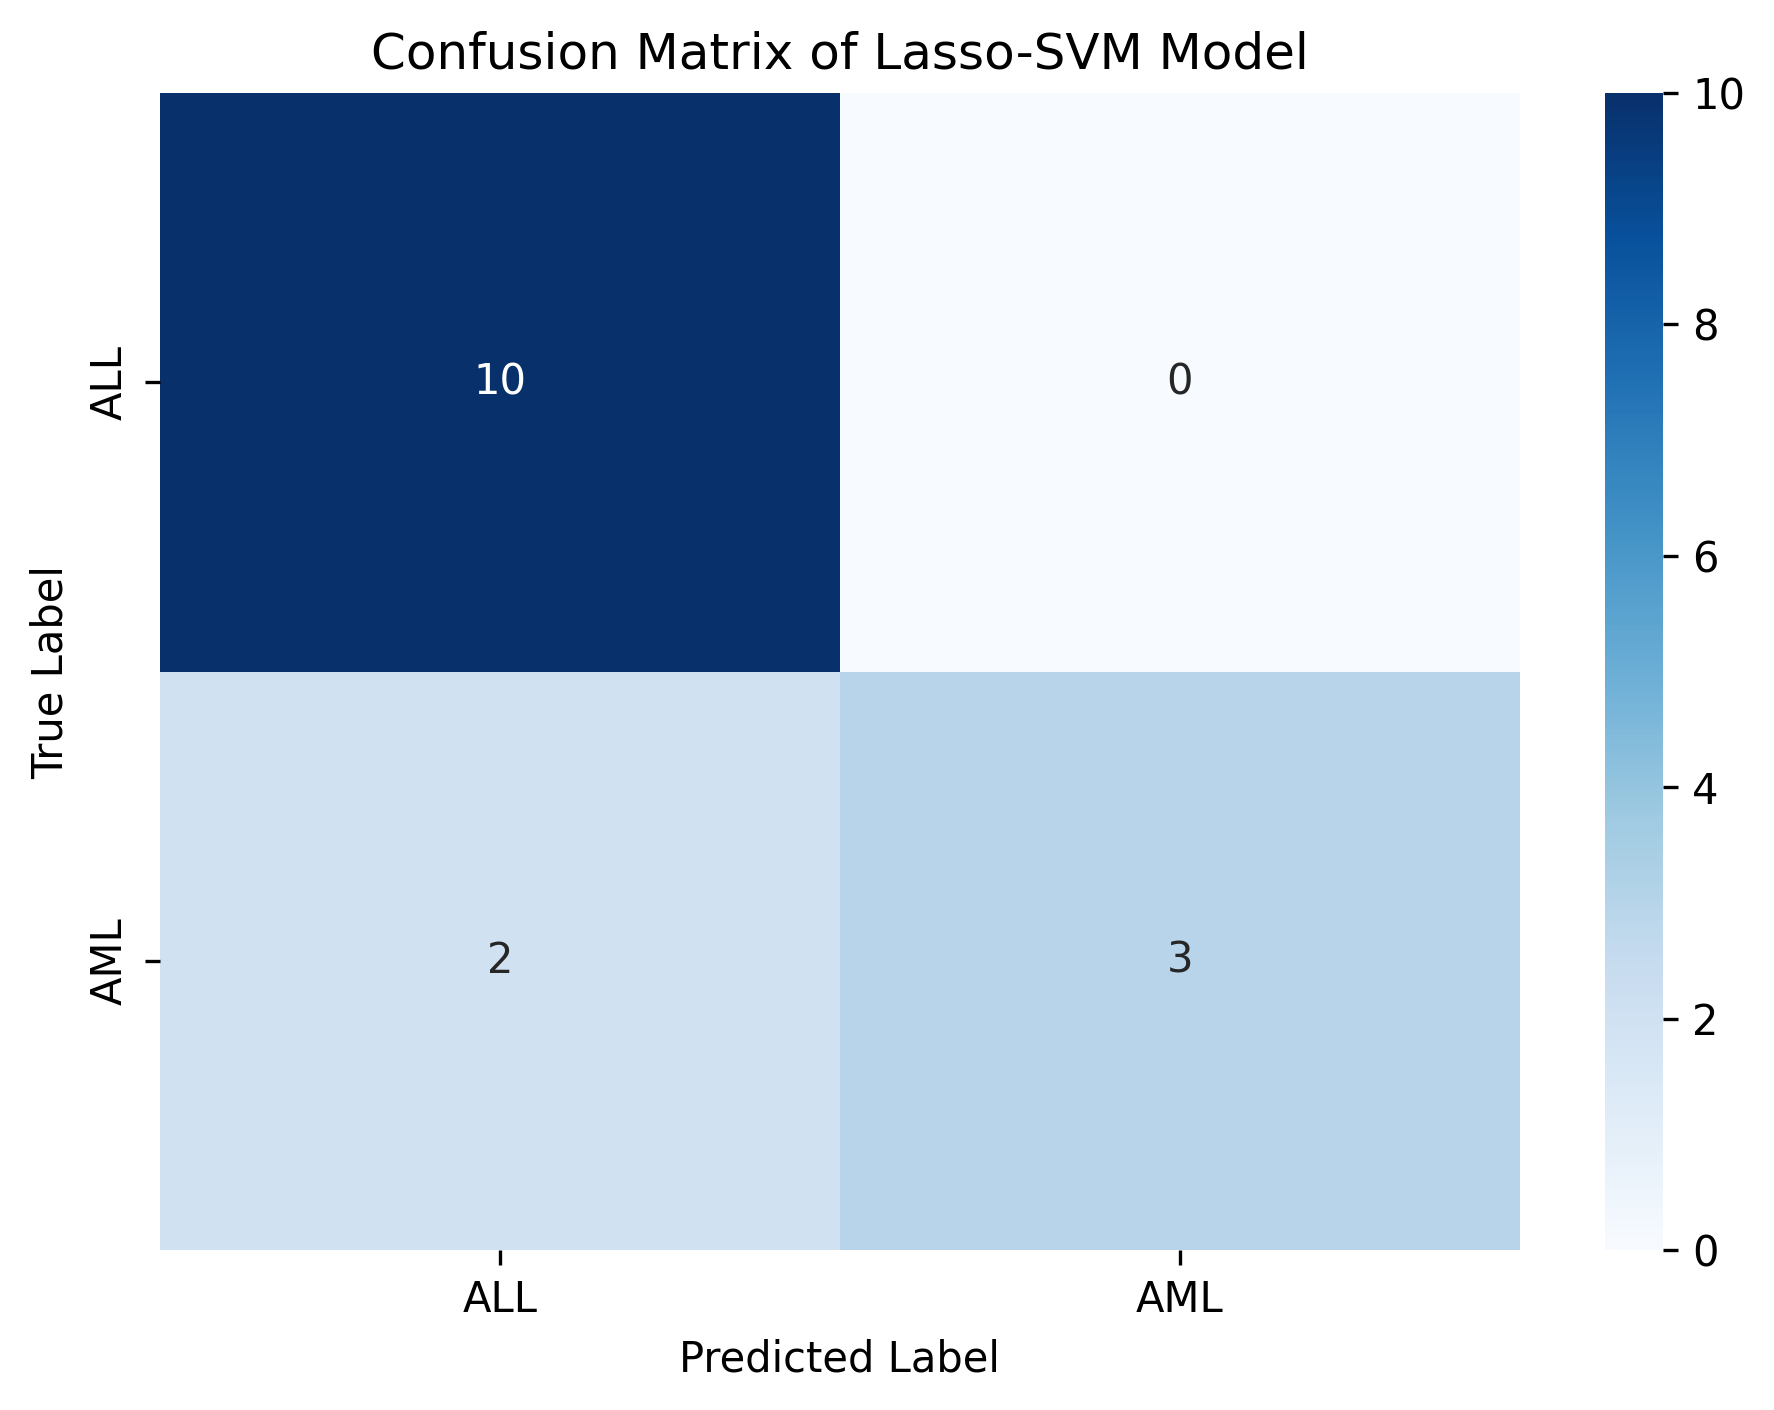

In [145]:
# using gridsearch to find the best parameters
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(random_state=42)
grid_svm_lasso = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy')
grid_svm_lasso.fit(X_train_lasso, y_train)

print(f"Best parameter of Lasso-SVM: {grid_svm_lasso.best_params_}")
print(f"Best accuracy of Lasso-SVM: {grid_svm_lasso.best_score_:.4f}")

y_pred = grid_svm_lasso.predict(X_test_lasso)
accuracy = accuracy_score(y_test, y_pred)

print(f"Best accuracy of Lasso-SVM: {accuracy:.4f}")


plt.figure(dpi = 300)
cm = confusion_matrix(y_test, y_pred)

labels = ['ALL', 'AML']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix of Lasso-SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plt/lasso-svm-confusion-matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

### **3.3 XGBoost**

Best parameter of Lasso-XGB: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 70, 'subsample': 0.8}
Best accuracy of Lasso-XGB: 0.9667
Accuracy of Lasso-XGB: 0.8667


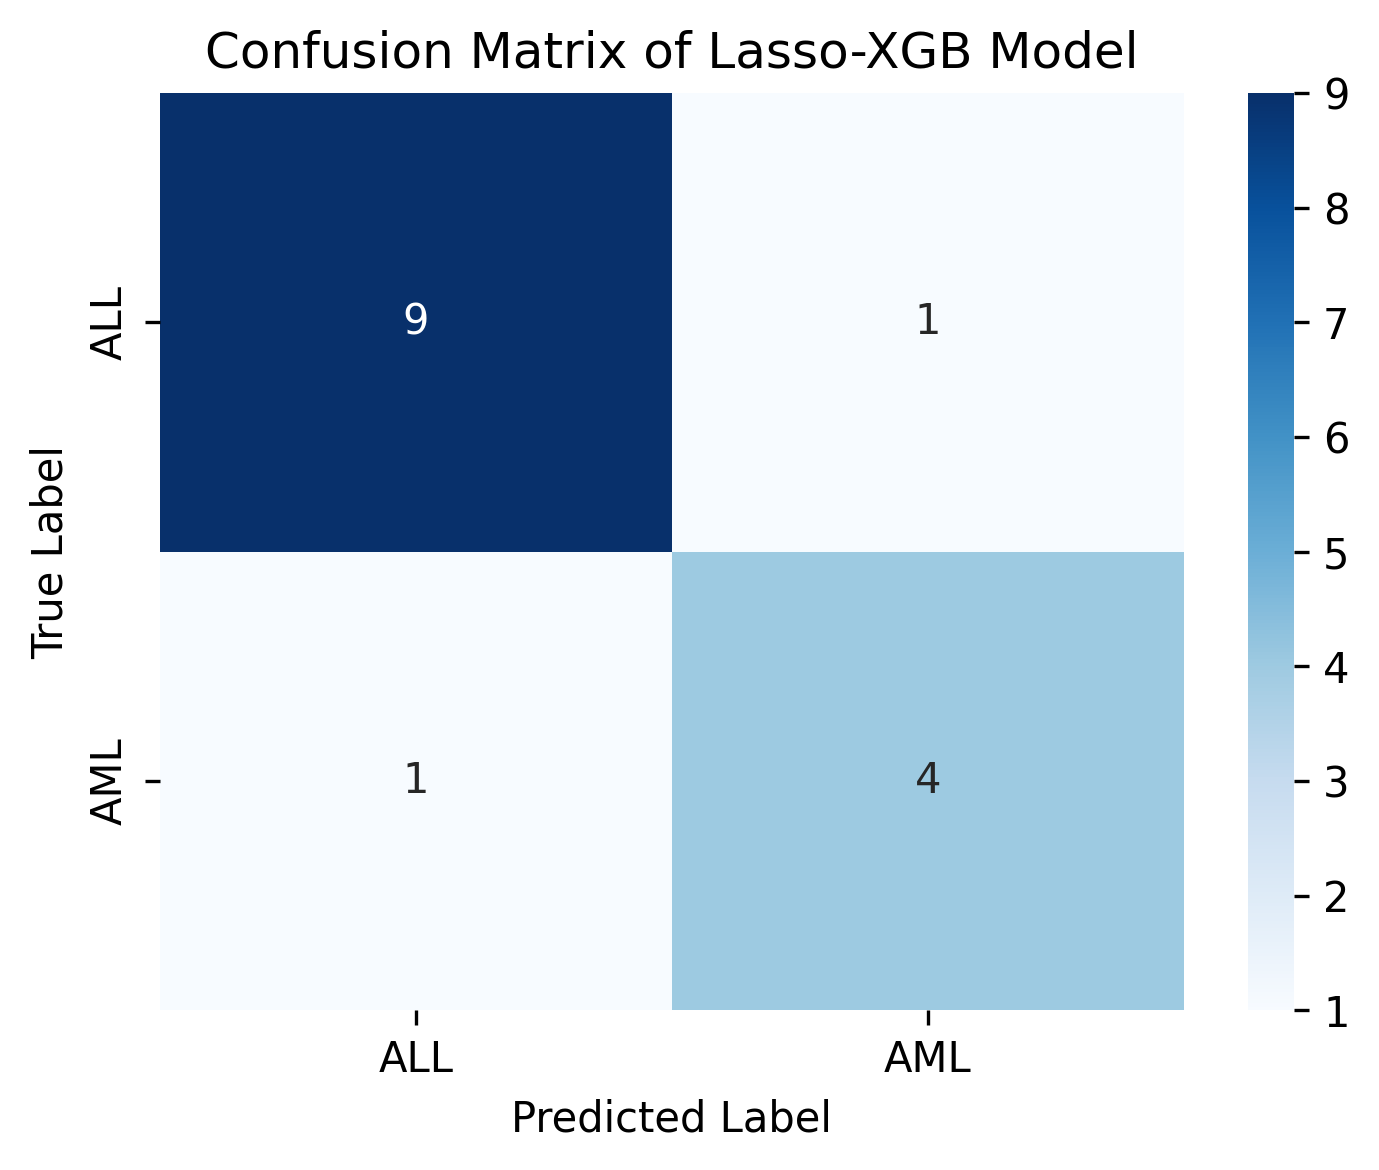

In [146]:
# Gridsearch-XGBoost
param_grid_xgb = {
    'n_estimators': [30, 50, 70],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'subsample': [0.7, 0.8, 0.9]
}

grid_xgb_lasso = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_xgb_lasso.fit(X_train_lasso, y_train)

print(f"Best parameter of Lasso-XGB: {grid_xgb_lasso.best_params_}")
print(f"Best accuracy of Lasso-XGB: {grid_xgb_lasso.best_score_:.4f}")

y_pred = grid_xgb_lasso.predict(X_test_lasso)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of Lasso-XGB: {accuracy:.4f}")

plt.figure(figsize = (5,4), dpi = 300)
cm = confusion_matrix(y_test, y_pred)

labels = ['ALL', 'AML']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix of Lasso-XGB Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plt/lasso-xgb-confusion-matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()